# Install Atari

In [1]:
!pip install -q "gymnasium[atari]" ale-py autorom[accept-rom-license]
!AutoROM --accept-license

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 6.2 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
/usr/local/lib/python3.12/dist-packages/AutoROM/AutoROM.py:264: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.


# IMPORTS, W&B, AND Reproducibility

In [2]:
import os
import random
import json
import warnings
from collections import deque
import copy


import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn.utils import clip_grad_norm_

import matplotlib.pyplot as plt

import ale_py
gym.register_envs(ale_py)  # explicit registration;

# Authenticate Weights & Biases via Kaggle Secrets
try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    os.environ["WANDB_API_KEY"] = user_secrets.get_secret("WANDB_API_KEY")
    os.environ["WANDB_SILENT"] = "true"  # Suppress CLI logs to keep Kaggle stdout clean
    print("W&B Authenticated successfully via Kaggle Secrets.")
except Exception as e:
    print("Kandle Secrets warning: WANDB_API_KEY not found. W&B logging will default to offline mode.")
    os.environ["WANDB_MODE"] = "offline"

import wandb

# Robust reproducibility manager
def set_seed(env, seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    print(f"CUDA-stable random seeds initialized at: {seed}")

W&B Authenticated successfully via Kaggle Secrets.


In [3]:
def get_env_short_name(env_name: str) -> str:
    """Turns 'ALE/Breakout-v5' -> 'breakout', 'MinAtar/breakout-v0' -> 'minatar_breakout'."""
    if "ALE/" in env_name:
        return env_name.split("/")[-1].split("-v")[0].lower()
    if "MinAtar" in env_name:
        return "minatar_" + env_name.split("/")[-1].split("-v")[0].lower()
    return env_name.lower()

def get_component_tag(config: dict) -> str:
    """Builds a short tag from whichever Rainbow components are active, e.g. 'double+dueling'."""
    components = []
    if config.get("double_dqn"): components.append("double")
    if config.get("dueling"): components.append("dueling")
    if config.get("n_step_learning"): components.append("nstep")
    if config.get("prioritized_replay"): components.append("per")
    if config.get("categorical_dqn"): components.append("c51")
    if config.get("noisy_nets"): components.append("noisy")
    return "+".join(components) if components else "vanilla"

In [4]:
def get_action_labels(env_name: str, seed: int) -> list[str]:
    """Returns human-readable action names where available (ALE envs), else generic a0/a1/... fallback."""
    env = make_env(env_name, seed)
    try:
        meanings = env.unwrapped.get_action_meanings()
    except AttributeError:
        meanings = [f"a{i}" for i in range(env.action_space.n)]
    env.close()
    return meanings

In [5]:
# Serializer to recursively handle NumPy types & nested data ===
def make_json_safe(obj):
    """Recursively converts NumPy arrays, scalars, and types to JSON-serializable Python types."""
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.floating, np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.integer, np.int32, np.int64)):
        return int(obj)
    elif isinstance(obj, (np.bool_, bool)):
        return bool(obj)
    elif isinstance(obj, type):
        return obj.__name__
    return obj

In [30]:
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_and_show(filename: str, dpi: int = 300):
    """Saves the active Matplotlib figure cleanly before rendering it to the screen."""
    filepath = os.path.join(FIG_DIR, filename)
    plt.savefig(filepath, dpi=dpi, bbox_inches="tight")
    print(f"Figure saved to: {filepath}")
    plt.show()
    plt.close()

## Configurations 

In [6]:
CONFIG = {
    "env_name": "ALE/Freeway-v5",
    "seed": 777,
    "total_frames": 100000,
    "memory_size": 100000,
    "batch_size": 32,
    "target_update": 2000,
    "learning_rate": 0.0001,
    "adam_eps": 0.00015,
    "gamma": 0.99,
    "min_replay_history": 1600,
    "max_grad_norm": 10.0,
    "eps_decay_steps": 20000, 
    "double_dqn": True,
    "dueling": False,
    "n_step_learning": False,
    "prioritized_replay": False,
    "categorical_dqn": False,
    "noisy_nets": False,
    "n_step": 20,
    "per_alpha": 0.5,
    "per_beta_initial": 0.4,
    "per_prior_eps": 1e-6,
    "c51_v_min": -10.0,
    "c51_v_max": 10.0,
    "c51_atom_size": 51,
    "noisy_std_init": 0.1,
}

In [7]:
ARCH_REGISTRY = {
    "minatar": {"conv_layers": [(16, 3, 1)], 
                "hidden_dim": 128, 
                "obs_dtype": np.float32, 
                "normalize": False},
    
    "atari":   {"conv_layers": [(32, 5, 5), (64, 5, 5)], 
                "hidden_dim": 256, 
                "obs_dtype": np.uint8, 
                "normalize": True},
}

def get_arch_for_env(env_name: str) -> dict:
    if "MinAtar" in env_name:
        return ARCH_REGISTRY["minatar"]
    elif "ALE/" in env_name:
        return ARCH_REGISTRY["atari"]
    return {}

In [8]:
CONFIG.update(get_arch_for_env(CONFIG["env_name"]))

In [9]:
import json

def save_checkpoint(agent, frame_idx, scores, losses, config: dict, filepath="checkpoint_latest.pth"):
    """Saves network parameters and training state to disk."""
    checkpoint = {
        'frame_idx': frame_idx,
        'scores': scores,
        'losses': losses,
        'config': config,  # this run's actual config, not the global CONFIG
        'model_state_dict': agent.dqn.state_dict(),
        'target_state_dict': agent.dqn_target.state_dict(),
        'optimizer_state_dict': agent.optimizer.state_dict(),
    }

    if config.get("prioritized_replay", False) and hasattr(agent, 'memory'):
        checkpoint['memory_tree_ptr'] = agent.memory.tree_ptr
        checkpoint['memory_max_priority'] = agent.memory.max_priority

    torch.save(checkpoint, filepath)

    metadata = {
        "frame_idx": frame_idx,
        "config": make_json_safe(config),
        "recent_avg_score": float(np.mean(scores[-10:])) if scores else 0.0
    }
    with open(filepath.replace(".pth", "_metadata.json"), "w") as f:
        json.dump(metadata, f, indent=4)

    print(f"Checkpoint successfully written to {filepath} at step {frame_idx}")

def load_checkpoint(agent, filepath="checkpoint_latest.pth"):
    """Loads a previously saved training run."""
    if not os.path.exists(filepath):
        print(f"No checkpoint found at {filepath}. Starting training from scratch.")
        return 0, [], []
        
    checkpoint = torch.load(filepath, map_location=agent.device)
    agent.dqn.load_state_dict(checkpoint['model_state_dict'])
    agent.dqn_target.load_state_dict(checkpoint['target_state_dict'])
    agent.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    print(f"Checkpoint loaded successfully from {filepath}. Resuming from step {checkpoint['frame_idx']}")
    return checkpoint['frame_idx'], checkpoint['scores'], checkpoint['losses']

## Loading the Environment

In [10]:
def make_env(env_name: str, seed: int):
    """
    Instantiates the requested environment and returns
    a unified Gymnasium-compatible interface.
    """

    # --------------------------------------
    # MINATAR
    # --------------------------------------

    if "MinAtar" in env_name:

        env = MinAtarGymWrapper(env_name)
        
    elif "ALE/" in env_name:
        env = gym.make(env_name, frameskip = 1)
        env = gym.wrappers.AtariPreprocessing(
            env,
            frame_skip = 4,
            screen_size = 84,
            grayscale_obs = True,
            terminal_on_life_loss = True,
            scale_obs = False,
        )
        env = gym.wrappers.FrameStackObservation(env, stack_size = 4)

    # --------------------------------------
    # STANDARD GYMNASIUM ENVIRONMENTS
    # --------------------------------------

    else:

        env = gym.make(env_name)

    # Apply reproducibility settings
    set_seed(env, seed)

    return env

In [11]:
def collect_holdout_states(env_name: str, seed: int = 999, obs_dtype=np.float32, num_states: int = 100) -> np.ndarray:
    """
    Deterministically collects a fixed set of holdout states using a dedicated constant seed.
    Because the seed and random policy are fixed, every isolated notebook/worker
    will produce the exact same holdout states.
    """
    env = make_env(env_name, seed)
    env.action_space.seed(seed)
    
    states = []
    # Seed the initial reset
    state, _ = env.reset(seed=seed)
    
    episode_seed_offset = 0
    while len(states) < num_states:
        # Action space is seeded, yielding deterministic random actions
        action = env.action_space.sample()
        next_state, _, terminated, truncated, _ = env.step(action)
        states.append(state)
        state = next_state
        
        if terminated or truncated:
            episode_seed_offset += 1
            state, _ = env.reset(seed=seed + episode_seed_offset)
            
    env.close()
    return np.array(states[:num_states], dtype=obs_dtype)

# Deep Q Network

## Pluggable Head for CNNs

In [12]:
def build_head(feat_size: int, out_dim: int, hidden_dim: int, dueling: bool = False, layer_fn=nn.Linear):
    """Builds the output head: a plain linear head, or a dueling value/advantage head."""
    if dueling:
        return DuelingHead(feat_size, out_dim, hidden_dim, layer_fn=layer_fn)
    return nn.Sequential(
        layer_fn(feat_size, hidden_dim), nn.ReLU(),
        layer_fn(hidden_dim, out_dim)
    )


class DuelingHead(nn.Module):
    """Splits features into a value stream V(s) and an advantage stream A(s, a),
    then recombines them into Q-values: Q = V + (A - mean(A)).
    layer_fn is injected (not hardcoded) so Noisy Nets can later swap in NoisyLinear
    here without touching this class."""
    def __init__(self, feat_size: int, out_dim: int, hidden_dim: int, layer_fn=nn.Linear):
        super().__init__()
        self.value_stream = nn.Sequential(
            layer_fn(feat_size, hidden_dim), nn.ReLU(),
            layer_fn(hidden_dim, 1)
        )
        self.advantage_stream = nn.Sequential(
            layer_fn(feat_size, hidden_dim), nn.ReLU(),
            layer_fn(hidden_dim, out_dim)
        )

    def forward(self, features):
        value = self.value_stream(features)
        advantage = self.advantage_stream(features)
        return value + (advantage - advantage.mean(dim=1, keepdim=True))
        
    def forward_streams(self, features):
        """Returns raw V(s) and A(s, a) streams separately for diagnostics."""
        value = self.value_stream(features)
        advantage = self.advantage_stream(features)
        return value, advantage

## Online Network

In [13]:
class Network(nn.Module):
    def __init__(self, in_dim: tuple, out_dim: int, conv_layers: list = None, hidden_dim: int = 128,
                 dueling: bool = False, layer_fn=nn.Linear):
        super().__init__()

        if len(in_dim) == 1:
            self.is_cnn = False
            self.body = nn.Sequential(nn.Linear(in_dim[0], hidden_dim), nn.ReLU())

        elif len(in_dim) == 3:
            self.is_cnn = True
            if conv_layers is None:
                raise ValueError("Pixel observations require a conv_layers spec.")
            in_channels = in_dim[0]
            layers = []
            for out_channels, kernel, stride in conv_layers:
                layers += [nn.Conv2d(in_channels, out_channels, kernel, stride), nn.ReLU()]
                in_channels = out_channels
            layers.append(nn.Flatten())
            self.body = nn.Sequential(*layers)

        else:
            raise ValueError(f"Observation space dimension shape {in_dim} is unsupported.")

        dummy = torch.zeros(1, *in_dim)
        with torch.no_grad():
            feat_size = self.body(dummy).shape[1]

        self.head = build_head(feat_size, out_dim, hidden_dim, dueling=dueling, layer_fn=layer_fn)

    def forward(self, x):
        return self.head(self.body(x))
        
    def forward_streams(self, x):
        """Passes input through body features, then extracts dual streams."""
        if not hasattr(self.head, "forward_streams"):
            raise ValueError("forward_streams is only available for Dueling architectures.")
        features = self.body(x)
        return self.head.forward_streams(features)


## Uniform Replay Buffer

In [14]:
class ReplayBuffer:
    """A simple, pre-allocated uniform NumPy replay buffer."""
    def __init__(self, obs_dim: tuple, size: int, batch_size: int = 32, obs_dtype=np.float32):
        """Pre-allocates memory buffers for sequential transitions."""
        # Pre-allocate contiguous memory blocks for optimal CPU/GPU cache hits
        self.obs_buf = np.zeros((size, *obs_dim), dtype=obs_dtype)
        self.next_obs_buf = np.zeros((size, *obs_dim), dtype=obs_dtype)
        self.acts_buf = np.zeros(size, dtype=np.float32)
        self.rews_buf = np.zeros(size, dtype=np.float32)
        self.terminated_buf = np.zeros(size, dtype=np.float32)
        
        # Buffer dimensions
        self.max_size = size
        self.batch_size = batch_size
        
        # Circular array pointers
        self.ptr = 0
        self.size = 0

    def store(
        self, 
        obs: np.ndarray, 
        act: int, 
        rew: float, 
        next_obs: np.ndarray, 
        terminated: bool
    ):
        """Pushes a single environment transition into the buffer."""
        self.obs_buf[self.ptr] = obs
        self.next_obs_buf[self.ptr] = next_obs
        self.acts_buf[self.ptr] = act
        self.rews_buf[self.ptr] = rew
        self.terminated_buf[self.ptr] = terminated
        
        # Circular write pointer logic
        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample_batch(self) -> dict[str, np.ndarray]:
        """Randomly samples a mini-batch of transitions."""
        # Uniform sampling without replacement
        idxs = np.random.choice(self.size, size=self.batch_size, replace=False)
        
        return dict(
            obs=self.obs_buf[idxs],
            next_obs=self.next_obs_buf[idxs],
            acts=self.acts_buf[idxs],
            rews=self.rews_buf[idxs],
            terminated=self.terminated_buf[idxs]
        )

    def __len__(self) -> int:
        """Returns the current quantity of stored transitions."""
        return self.size

## N-Step Return Accumulator


In [15]:
class NStepBuffer:
    """Sliding-window n-step return accumulator.

    Holds the most recent `n_step` raw transitions in a deque. Each call to
    append() slides the window forward and, once full, emits the n-step
    transition anchored on the OLDEST (state, action) currently in the
    window: an n-step discounted return and the next_state/terminated
    reached at the end of the window -- stopping the discounted sum early
    if a terminal was hit inside the window (in which case the bootstrap
    term will be zeroed out downstream by `(1 - terminated)`, so an
    understated discount exponent there is harmless).

    flush() drains the tail of an episode: the last (n_step - 1) real
    transitions that were stored but never got to see a full window, each
    emitted with a correspondingly shorter return.
    """
    def __init__(self, n_step: int, gamma: float):
        self.n_step = n_step
        self.gamma = gamma
        self.buffer = deque(maxlen=n_step)

    def append(self, state, action, reward, next_state, terminated):
        """Pushes one raw transition into the window. Returns the n-step
        transition once the window is full, else None."""
        self.buffer.append((state, action, reward, next_state, terminated))
        if len(self.buffer) < self.n_step:
            return None
        return self._n_step_transition()

    def _n_step_transition(self):
        """Collapses the current window into a single n-step transition."""
        state, action = self.buffer[0][0], self.buffer[0][1]
        n_step_return = 0.0
        next_state, terminated = self.buffer[-1][3], self.buffer[-1][4]
        for i, (_, _, r, n_s, term) in enumerate(self.buffer):
            n_step_return += (self.gamma ** i) * r
            if term:
                next_state, terminated = n_s, term
                break
        return state, action, n_step_return, next_state, terminated

    
    def flush(self):
        """Called on episode end: emits shrinking-window transitions for
        whatever is left in the buffer, then clears it."""
        transitions = []
        while self.buffer:
            transitions.append(self._n_step_transition())
            self.buffer.popleft()
        return transitions

    def reset(self):
        """Clears the window without emitting anything (safety net for a
        mid-episode reset that isn't a normal `done`)."""
        self.buffer.clear()


## Epsilon Greedy Exploration Strategy for Agent

In [16]:
class EpsilonGreedyStrategy:
    """Manages linear epsilon decay and discrete action selection."""
    def __init__(
        self, 
        action_dim: int, 
        eps_start: float = 1.0, 
        eps_end: float = 0.1, 
        decay_steps: int = 10000
    ):
        """Initializes the exploration range and schedule parameters."""
        self.action_dim = action_dim
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.decay_steps = decay_steps
        self.current_step = 0

    def get_epsilon(self) -> float:
        """Calculates the decayed epsilon value for the current step."""
        # Calculate the linear interpolation progress bounded by [0.0, 1.0]
        fraction = min(float(self.current_step) / self.decay_steps, 1.0)
        epsilon = self.eps_start + fraction * (self.eps_end - self.eps_start)
        return epsilon

    def explore_or_exploit(self, q_values: np.ndarray) -> int:
        """Selects an action epsilon-greedily based on predicted values."""
        epsilon = self.get_epsilon()
        self.current_step += 1 # Auto-increment step tracking on every decision call
        
        if random.random() < epsilon:
            # Explore: Select a completely random action from the space
            return random.randrange(self.action_dim)
        else:
            # Exploit: Select the action yielding the highest predicted Q-value (argmax)
            return int(np.argmax(q_values))

## Target Network Synchronization

In [17]:
def target_hard_update(online_net: nn.Module, target_net: nn.Module):
    """Hard updates the target network weights from the online network."""
    # load_state_dict directly copies the parameters from the source network's state_dict
    target_net.load_state_dict(online_net.state_dict())
    

def setup_networks(in_dim, out_dim, device, conv_layers=None, hidden_dim=128, dueling=False):
    """Creates the online and target networks and synchronizes them."""
    #  Initialize the online Q-network (this is actively optimized via backprop)
    online_net = Network(in_dim, out_dim, conv_layers=conv_layers, hidden_dim=hidden_dim, dueling=dueling).to(device)
    
     # Initialize the target Q-network (this is used strictly to calculate targets)
    target_net = Network(in_dim, out_dim, conv_layers=conv_layers, hidden_dim=hidden_dim, dueling=dueling).to(device)
    
    # Synchronize their weights at the very start of training
    target_hard_update(online_net, target_net)

    # Enforce evaluation mode on the target network
    # This disables dropout layers, batch normalization updates, and parameter noise calculations
    target_net.eval()
    
    return online_net, target_net

##  DQN Agent

In [18]:
class DQNAgent:
    """DQN Agent implementing standard Vanilla DQN training and action selection."""
    def __init__(
        self, 
        env: gym.Env,
        config: dict,
        seed: int,
    ):
        """Initializes agent configurations, networks, memory buffers, and schedules."""
        # Setup environment properties
        obs_dim = env.observation_space.shape
        action_dim = env.action_space.n
        self.config = config
        self.env = env
        self.batch_size = config["batch_size"]
        self.target_update = config["target_update"]
        self.seed = seed
        self.gamma = config["gamma"]
        self.min_replay_history = config.get("min_replay_history", config["batch_size"])

        # N-step returns: config-gated, defaults to plain 1-step behavior
        self.use_n_step = config.get("n_step_learning", False)
        self.n_step = config.get("n_step", 1) if self.use_n_step else 1
        if self.use_n_step:
            self.n_step_buffer = NStepBuffer(self.n_step, self.gamma)
        
        # Detect hardware target
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Agent executing on hardware: {self.device}")
        
        # Instantiate networks (from Step 4)
        self.dqn, self.dqn_target = setup_networks(obs_dim, 
                                                   action_dim, 
                                                   self.device,
                                                   conv_layers = config.get("conv_layers"),
                                                   hidden_dim = config.get("hidden_dim", 128),
                                                   dueling = config.get("dueling", False),
                                                  )
        
        # Instantiate uniform memory buffer (from Step 2)
        self.memory = ReplayBuffer(obs_dim, config["memory_size"], config["batch_size"], obs_dtype=config.get("obs_dtype", np.float32))
        
        # Instantiate epsilon-greedy exploration strategy (from Step 3)
        # We start with a conservative 10,000 steps decay schedule
        self.exploration = EpsilonGreedyStrategy(action_dim, decay_steps=config.get("eps_decay_steps", 10000))
        
        # Instantiate optimizer
        self.optimizer = optim.Adam(self.dqn.parameters(), lr=config["learning_rate"])
        
        # Internal placeholders
        self.transition = list()
        self.is_test = False
        
        self.action_dim = action_dim

    def select_action(self, state: np.ndarray) -> int:
        """Selects a discrete action based on the active state."""
        
        # Convert state array to float tensor, add batch dimension, and load to GPU
        state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        
        if self.config.get("normalize", False):
            state_t = state_t / 255.0
        
        # Predict actions without tracking gradients
        with torch.no_grad():
            q_values_t = self.dqn(state_t)
        q_values = q_values_t.cpu().squeeze(0).numpy()
        
        # Pass the predicted Q-values to the epsilon schedule
        action = self.exploration.explore_or_exploit(q_values)
        
        # Record state and action for buffer storage
        if not self.is_test:
            self.transition = [state, action]
            
        return action

    def step(self, action: int) -> tuple[np.ndarray, float, bool]:
        """Executes an action, fetches responses, and stores transition to buffer."""
        next_state, reward, terminated, truncated, _ = self.env.step(action)
        done = terminated or truncated
        
        # Reward clipping for training stability
        raw_reward = reward
        clipped_reward = float(np.sign(reward))

        # Store state, action, reward, next_state, and terminated status
        if not self.is_test:
            self.transition += [clipped_reward, next_state, terminated]

            if self.use_n_step:
                # Slide the transition through the n-step window; only store
                # once we have a full (or, at episode end, partial) return.
                ready = self.n_step_buffer.append(*self.transition)
                if ready is not None:
                    self.memory.store(*ready)
                if done:
                    for n_step_transition in self.n_step_buffer.flush():
                        self.memory.store(*n_step_transition)
            else:
                self.memory.store(*self.transition)
            
        return next_state, raw_reward, done
    
    
    def compute_dqn_loss(self, samples: dict[str, np.ndarray], return_td_errors: bool = False) -> torch.Tensor:
        """Calculates standard 1-step / n-step Mean Squared Error loss."""
        # Convert NumPy arrays from buffer to PyTorch tensors and send directly to GPU
        states = torch.as_tensor(samples["obs"], dtype=torch.float32, device=self.device)
        next_states = torch.as_tensor(samples["next_obs"], dtype=torch.float32, device=self.device)
        actions = torch.as_tensor(samples["acts"], dtype=torch.int64, device=self.device).unsqueeze(1)
        rewards = torch.as_tensor(samples["rews"], dtype=torch.float32, device=self.device).unsqueeze(1)
        terminated = torch.as_tensor(samples["terminated"], dtype=torch.float32, device=self.device).unsqueeze(1)
        
        if self.config.get("normalize", False):
            states = states / 255.0
            next_states = next_states / 255.0
        
        # 1. Predict Q(s, a) using the main network
        current_q = self.dqn(states).gather(1, actions)
        
        # 2. Predict max Q(s', a') using the target network (without tracking gradients)
        with torch.no_grad():
            if self.config.get("double_dqn", False):
                next_actions = self.dqn(next_states).argmax(dim=1, keepdim=True)
                next_q = self.dqn_target(next_states).gather(1, next_actions)
            else:
                next_q = self.dqn_target(next_states).max(dim=1, keepdim=True)[0]
        
        # 3. Calculate n-step Bellman Target
        gamma_n = self.gamma ** self.n_step
        target_q = rewards + (1.0 - terminated) * gamma_n * next_q
        
        # 4. Calculate Mean Squared Error
        td_errors = target_q - current_q
        loss = F.mse_loss(current_q, target_q)
        
        if return_td_errors:
            return loss, td_errors.detach().squeeze().cpu().numpy()
        return loss

    
    def update_model(self, record_td_errors: bool = False):
        """Runs a single gradient descent step on a sampled batch."""
        samples = self.memory.sample_batch()
        
        # Pass the flag down to compute_dqn_loss
        if record_td_errors:
            loss, td_errors = self.compute_dqn_loss(samples, return_td_errors=True)
        else:
            loss = self.compute_dqn_loss(samples, return_td_errors=False)
            td_errors = None
        
        self.optimizer.zero_grad()
        loss.backward()
        
        # Clip gradient norm to 10.0 to prevent gradient explosions
        clip_grad_norm_(self.dqn.parameters(), 10.0)
        self.optimizer.step()
        
        return loss.item(), td_errors
    

    def train(self, num_frames: int, plotting_interval: int = 1000, holdout_states: np.ndarray = None, action_track_window: int = 5000):
        """Executes the standard, sequential training loop."""
        self.is_test = False
        state, _ = self.env.reset(seed=self.seed)
        update_cnt = 0
        
        losses = []
        scores = []
        lengths = []
        score = 0
        ep_len = 0

        # Initialize metric tracking lists 
        self.loss_history = []          # Logs (frame_idx, loss_value)
        self.q_drift = []               # Logs (frame_idx, mean_max_q)
        self.dueling_metrics = []       # Logs (frame_idx, mean_abs_v, adv_spread)
        self.td_error_checkpoints = {}  # Logs {frame_idx: td_error_array}
        self.action_history = []        # Logs (frame_idx, action_percentage_list)
        
        # Pre-convert holdout states once, if provided, for Q-drift tracking
        self.q_drift = []
        
        # Initialize list to log Dueling stream decomposition dynamics 
        self.dueling_metrics = [] 

        # Define checkpoint frames and snapshot dictionary for TD-errors ===
        self.td_error_checkpoints = {}
        
        # Captures distributions at 25%, 50%, 75%, and 100% of training budget
        checkpoint_milestones = set([max(1, int(num_frames * p)) for p in [0.25, 0.50, 0.75, 1.0]])
        
        holdout_tensor = None
        
        if holdout_states is not None:
            holdout_tensor = torch.FloatTensor(holdout_states).to(self.device)
            if self.config.get("normalize", False):
                holdout_tensor = holdout_tensor / 255.0
                
        # Action-distribution tracking
        self.action_history = []
        action_counts = np.zeros(self.action_dim)
                
        for frame_idx in range(1, num_frames + 1):
            action = self.select_action(state)
            action_counts[action] += 1
            next_state, reward, done = self.step(action)
            
            state = next_state
            score += reward
            ep_len += 1

            if done:
                # Reset environment when episode ends and save final score
                state, _ = self.env.reset(seed=self.seed)
                scores.append(score)
                lengths.append(ep_len)
                score = 0
                ep_len = 0
                
            #  Check if this frame is a TD-error distribution milestone ===
            record_this_step = frame_idx in checkpoint_milestones

            # Begin model updates only after collecting enough steps
            # if len(self.memory) >= self.min_replay_history:
            #     loss = self.update_model()
            #     losses.append(loss)
            #     update_cnt += 1

            #     # Periodically sync main weights to target network
            #     if update_cnt % self.target_update == 0:
            #         target_hard_update(self.dqn, self.dqn_target)

        
            if len(self.memory) >= self.min_replay_history:
                loss_val, batch_td_errors = self.update_model(record_td_errors=record_this_step)
                losses.append(loss_val)
                update_cnt += 1
                
                # Save snapshot array to checkpoint dictionary
                if record_this_step and batch_td_errors is not None:
                    self.td_error_checkpoints[frame_idx] = batch_td_errors
                    
                if update_cnt % self.target_update == 0:
                    target_hard_update(self.dqn, self.dqn_target)

                
            if frame_idx % plotting_interval == 0:
                avg_score = np.mean(scores[-10:]) if scores else 0.0
                latest_loss = losses[-1] if losses else 0.0

                self.loss_history.append((frame_idx, latest_loss))

                log_dict = {
                    "frame": frame_idx,
                    "avg_score_10": avg_score,
                    "loss": latest_loss,
                    "epsilon": self.exploration.get_epsilon(),
                    "buffer_size": len(self.memory),
                }

                # Q-drift: mean predicted max-Q over the fixed holdout batch
                if holdout_tensor is not None:
                    with torch.no_grad():
                        mean_max_q = self.dqn(holdout_tensor).max(dim=1)[0].mean().item()
                    self.q_drift.append((frame_idx, mean_max_q))
                    log_dict["holdout_mean_max_q"] = mean_max_q
                    
                if holdout_tensor is not None and self.config.get("dueling", False):
                    with torch.no_grad():
                        v_stream, a_stream = self.dqn.forward_streams(holdout_tensor)
                        # Metric 1: Mean Absolute State-Value magnitude E[|V(s)|]
                        mean_abs_v = v_stream.abs().mean().item()
                        # Metric 2: Mean Advantage Spread E[max_a A(s, a) - min_a A(s, a)]
                        adv_spread = (a_stream.max(dim=1)[0] - a_stream.min(dim=1)[0]).mean().item()
                        
                    self.dueling_metrics.append((frame_idx, mean_abs_v, adv_spread))
                    log_dict["dueling_mean_abs_v"] = mean_abs_v
                    log_dict["dueling_mean_adv_spread"] = adv_spread

                print(f"Frame {frame_idx}/{num_frames} | Recent Avg Score: {avg_score:.2f} | Loss: {latest_loss:.4f}")
                wandb.log(log_dict, step=frame_idx)
            
            # Action distribution snapshot every action_track_window frames
            if frame_idx % action_track_window == 0:
                total = action_counts.sum()
                pct = action_counts / total if total > 0 else action_counts
                self.action_history.append((frame_idx, pct.copy()))
                action_counts[:] = 0
                
                
                

        self.env.close()
        self.scores = scores
        self.losses = losses
        self.lengths = lengths

In [19]:
COMPONENT_DEFAULTS = {
    "double_dqn": False,
    "dueling": False,
    "n_step_learning": False,
    "prioritized_replay": False,
    "categorical_dqn": False,
    "noisy_nets": False,
}

# Experiments as data
EXPERIMENTS = {
    "vanilla": {},
    # "dueling": {"dueling": True},
    "double_dqn": {"double_dqn": True},
    # "multi_step": {"n_step_learning": True},
}

ENVIRONMENTS = [
    "ALE/Freeway-v5",
    "ALE/DemonAttack-v5",
    "ALE/Frostbite-v5",
    "ALE/Krull-v5"
    
 
]

SEEDS = [777, 42, 2024]

In [20]:
def build_config(base_config: dict, env_name: str, overrides: dict, seed: int) -> dict:
    """Builds one isolated CONFIG for a single run: base -> arch -> reset flags -> experiment overrides."""
    cfg = copy.deepcopy(base_config)
    cfg["env_name"] = env_name
    cfg["seed"] = seed  
    cfg.update(get_arch_for_env(env_name))
    cfg.update(COMPONENT_DEFAULTS)   # hard reset every component flag
    cfg.update(overrides)            # then apply only this experiment's flags
    return cfg


def run_experiment(base_config: dict, env_name: str, exp_name: str, overrides: dict, seed: int, holdout_states: np.ndarray) -> dict:
    """Runs one (environment, experiment) pair end to end and returns its results."""
    cfg = build_config(base_config, env_name, overrides, seed)
    env = make_env(cfg["env_name"], cfg["seed"])
    agent = DQNAgent(env=env, config=cfg, seed=cfg["seed"])
    # Epsilon decay is already correctly set inside DQNAgent.__init__ using cfg.get("eps_decay_steps")
    
    env_short = get_env_short_name(cfg["env_name"])
    component_tag = get_component_tag(cfg)
    checkpoint_path = f"checkpoint_{env_short}_{component_tag}_seed-{cfg['seed']}.pth"

    metrics_path = f"metrics_{env_short}_{component_tag}_seed-{cfg['seed']}.json"

    # GATING:  Activate holdout evaluation if Double DQN OR Dueling DQN is running
    needs_holdout = cfg.get("double_dqn", False) or cfg.get("dueling", False) or (component_tag == "vanilla")
    active_holdout = holdout_states if needs_holdout else None
    
    run = wandb.init(
        project="rainbow-ablation-atari",
        group=f"{env_short}_{component_tag}",
        name=f"{env_short}_{component_tag}_seed-{cfg['seed']}",
        config=cfg,
        reinit=True,
    )
    print(f"Running {component_tag} on {cfg['env_name']} (seed {cfg['seed']})...")
    agent.train(num_frames=cfg["total_frames"], plotting_interval=1000, holdout_states=holdout_states)
    save_checkpoint(agent, frame_idx=cfg["total_frames"], scores=agent.scores, losses=agent.losses,
                    config=cfg, filepath=checkpoint_path)
    wandb.finish
    
    # Build complete metrics artifact dictionary 
    result_data = {
        "env_name": cfg["env_name"],
        "experiment": exp_name,
        "tag": component_tag,
        "seed": int(cfg["seed"]),
        "config": make_json_safe(cfg),
        "scores": [float(s) for s in agent.scores],
        "episode_lengths": [int(l) for l in agent.lengths],
        "losses": [float(l) for l in agent.losses],
        "loss_history": agent.loss_history,
        "action_history": agent.action_history,
        "q_drift": agent.q_drift,
        "dueling_metrics": getattr(agent, "dueling_metrics", []),
        "td_error_checkpoints": getattr(agent, "td_error_checkpoints", {}),
        "checkpoint_path": checkpoint_path,
        "metrics_path": metrics_path,
    }
    
    # === [CHANGE]: Persist JSON artifact to disk for Kaggle Notebook Outputs ===
    with open(metrics_path, "w") as f:
        json.dump(make_json_safe(result_data), f, indent=2)
    print(f"Metrics artifact successfully saved to {metrics_path}")

    return result_data
    
       
def moving_average(data, window_size=10):
    """Smooths a sequence via a simple moving average."""
    if len(data) < window_size:
        return data
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

In [21]:
# Constant seed strictly used for generating identical holdout states across all notebooks
HOLDOUT_SEED = 999 

# Run the full grid
results = []
for env_name in ENVIRONMENTS:
    arch = get_arch_for_env(env_name)

    # Generate identical holdout states locally in this notebook session
    holdout_states = collect_holdout_states(
        env_name=env_name, 
        seed=HOLDOUT_SEED, 
        obs_dtype=arch.get("obs_dtype", np.float32), 
        num_states=100
    )
   
    for exp_name, overrides in EXPERIMENTS.items():
        for seed in SEEDS:
            result = run_experiment(CONFIG, env_name, exp_name, overrides, seed, holdout_states)
            results.append(result)

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


CUDA-stable random seeds initialized at: 999
CUDA-stable random seeds initialized at: 777
Agent executing on hardware: cuda


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


Running vanilla on ALE/Freeway-v5 (seed 777)...
Frame 1000/100000 | Recent Avg Score: 0.00 | Loss: 0.0000
Frame 2000/100000 | Recent Avg Score: 0.00 | Loss: 0.0000
Frame 3000/100000 | Recent Avg Score: 0.00 | Loss: 0.0000
Frame 4000/100000 | Recent Avg Score: 0.00 | Loss: 0.0000
Frame 5000/100000 | Recent Avg Score: 0.00 | Loss: 0.0000
Frame 6000/100000 | Recent Avg Score: 0.00 | Loss: 0.0000
Frame 7000/100000 | Recent Avg Score: 0.00 | Loss: 0.0000
Frame 8000/100000 | Recent Avg Score: 0.00 | Loss: 0.0000
Frame 9000/100000 | Recent Avg Score: 0.00 | Loss: 0.0000
Frame 10000/100000 | Recent Avg Score: 0.00 | Loss: 0.0000
Frame 11000/100000 | Recent Avg Score: 0.00 | Loss: 0.0000
Frame 12000/100000 | Recent Avg Score: 0.00 | Loss: 0.0000
Frame 13000/100000 | Recent Avg Score: 0.00 | Loss: 0.0000
Frame 14000/100000 | Recent Avg Score: 0.00 | Loss: 0.0000
Frame 15000/100000 | Recent Avg Score: 0.00 | Loss: 0.0000
Frame 16000/100000 | Recent Avg Score: 0.00 | Loss: 0.0000
Frame 17000/10000

In [22]:
def aggregate_seeds_by_frame(results: list, env_name: str, exp_name: str, key: str = "scores",
                              window_size: int = 10, band: str = "std", num_points: int = 200):
    """Aggregates a per-episode metric across seeds, aligned by cumulative
    training frame rather than episode index.

    Episode length isn't constant (it changes as the agent improves), so
    episode index i means a different amount of training data per seed --
    only cumulative frame count (from episode_lengths) is comparable. Each
    seed's smoothed-score series is built against its own cumulative frames,
    then linearly interpolated onto a frame grid shared across the seeds in
    this group, capped at the frame every seed actually reached (so no seed
    is extrapolated past its own data).
    """
    seed_series = []
    max_common_frame = None

    for r in results:
        if r["env_name"] != env_name or r["experiment"] != exp_name:
            continue
        scores = r[key]
        lengths = r["episode_lengths"]
        if not scores or not lengths:
            continue

        smoothed = moving_average(scores, window_size=window_size)
        cum_frames = np.cumsum(lengths)
        offset = len(scores) - len(smoothed)  # moving_average trims the leading window
        frame_x = cum_frames[offset:]

        if len(frame_x) == 0:
            continue
        seed_series.append((frame_x, smoothed))
        max_common_frame = frame_x[-1] if max_common_frame is None else min(max_common_frame, frame_x[-1])

    if not seed_series or not max_common_frame:
        return None

    grid = np.linspace(0, max_common_frame, num_points)
    interpolated = np.stack([np.interp(grid, fx, s) for fx, s in seed_series])

    if band == "iqr":
        center = np.median(interpolated, axis=0)
        lower = np.percentile(interpolated, 25, axis=0)
        upper = np.percentile(interpolated, 75, axis=0)
    else:
        center = interpolated.mean(axis=0)
        spread = interpolated.std(axis=0)
        lower, upper = center - spread, center + spread

    return grid, center, lower, upper

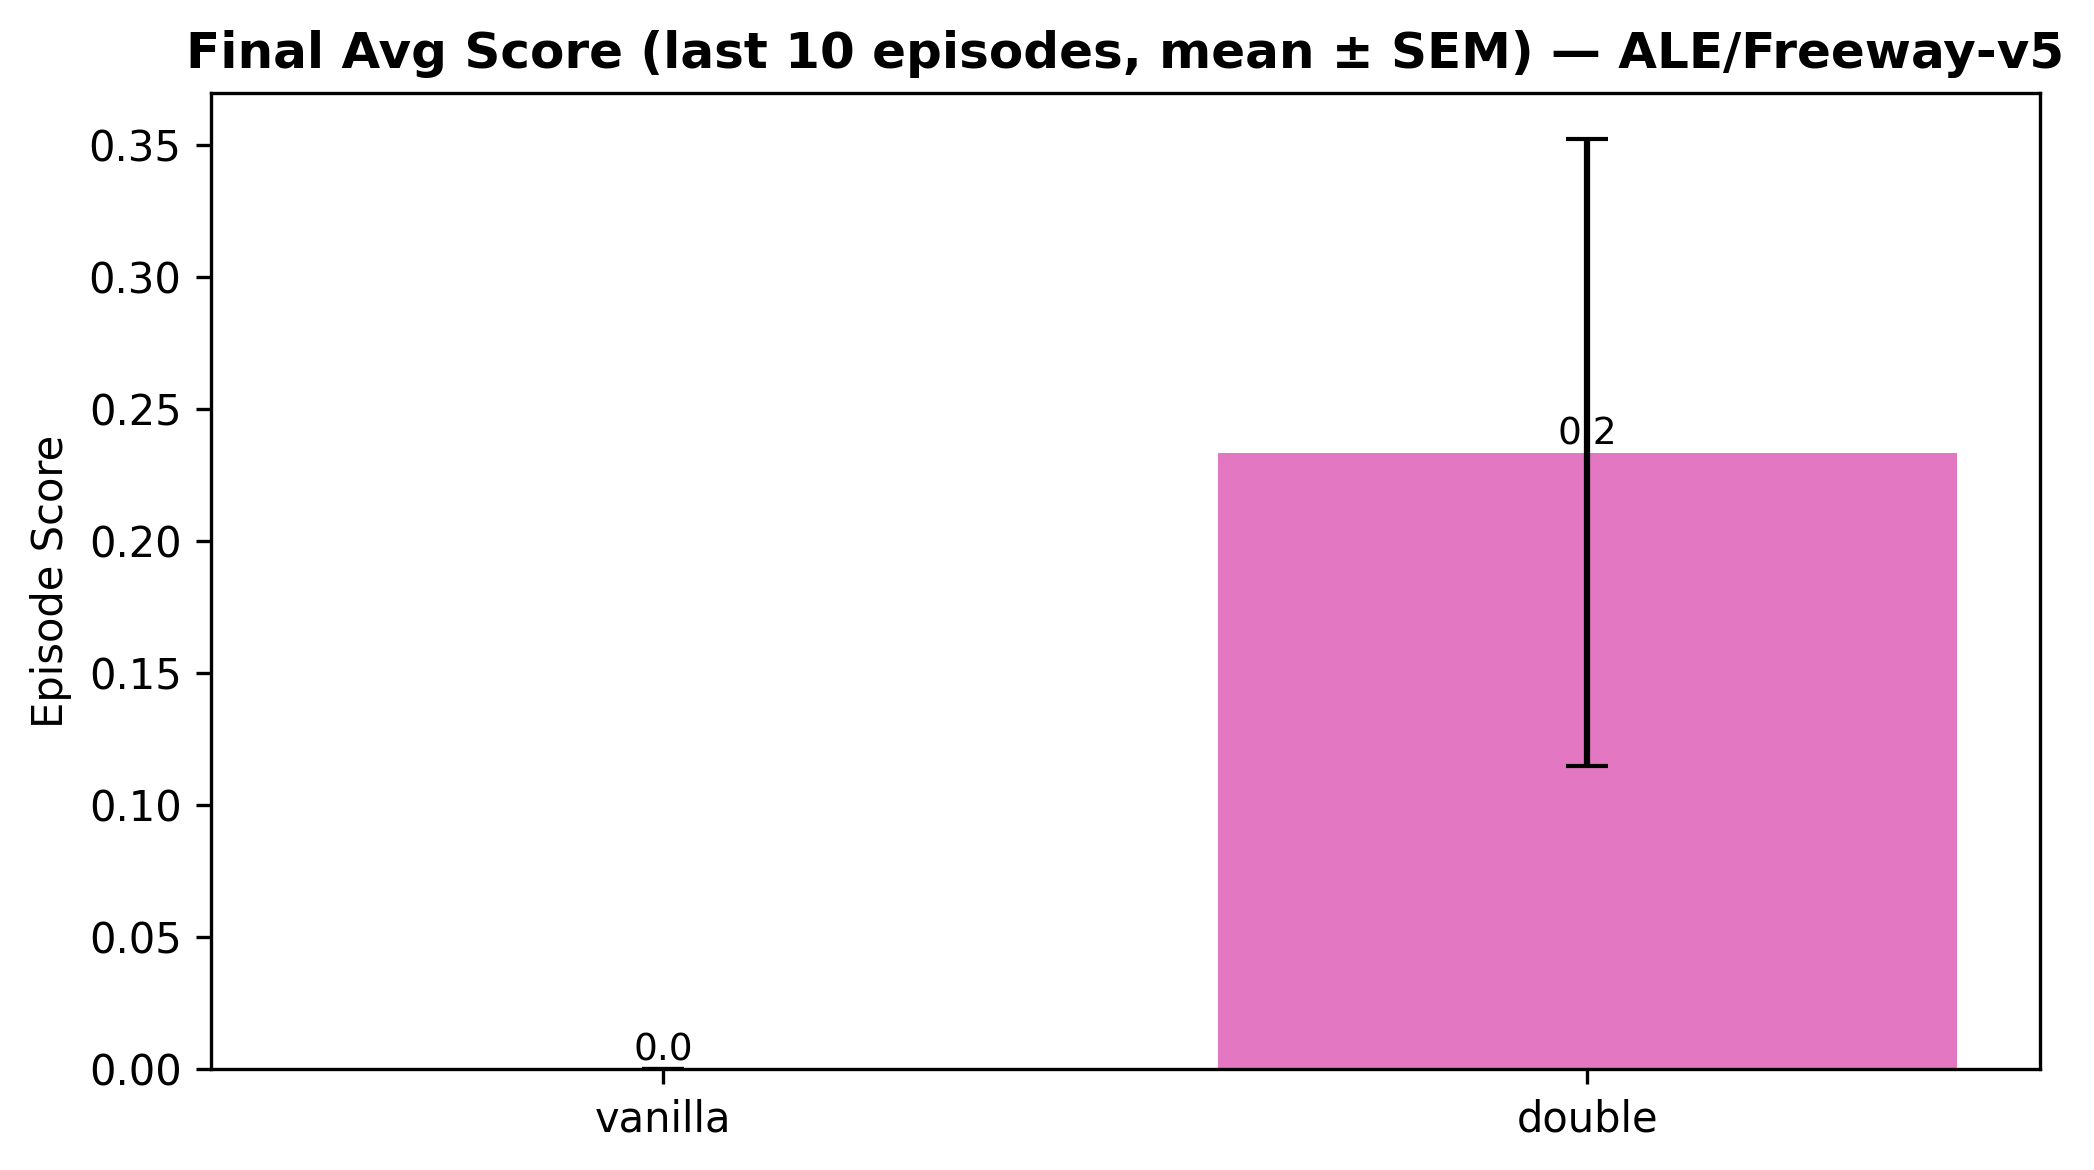

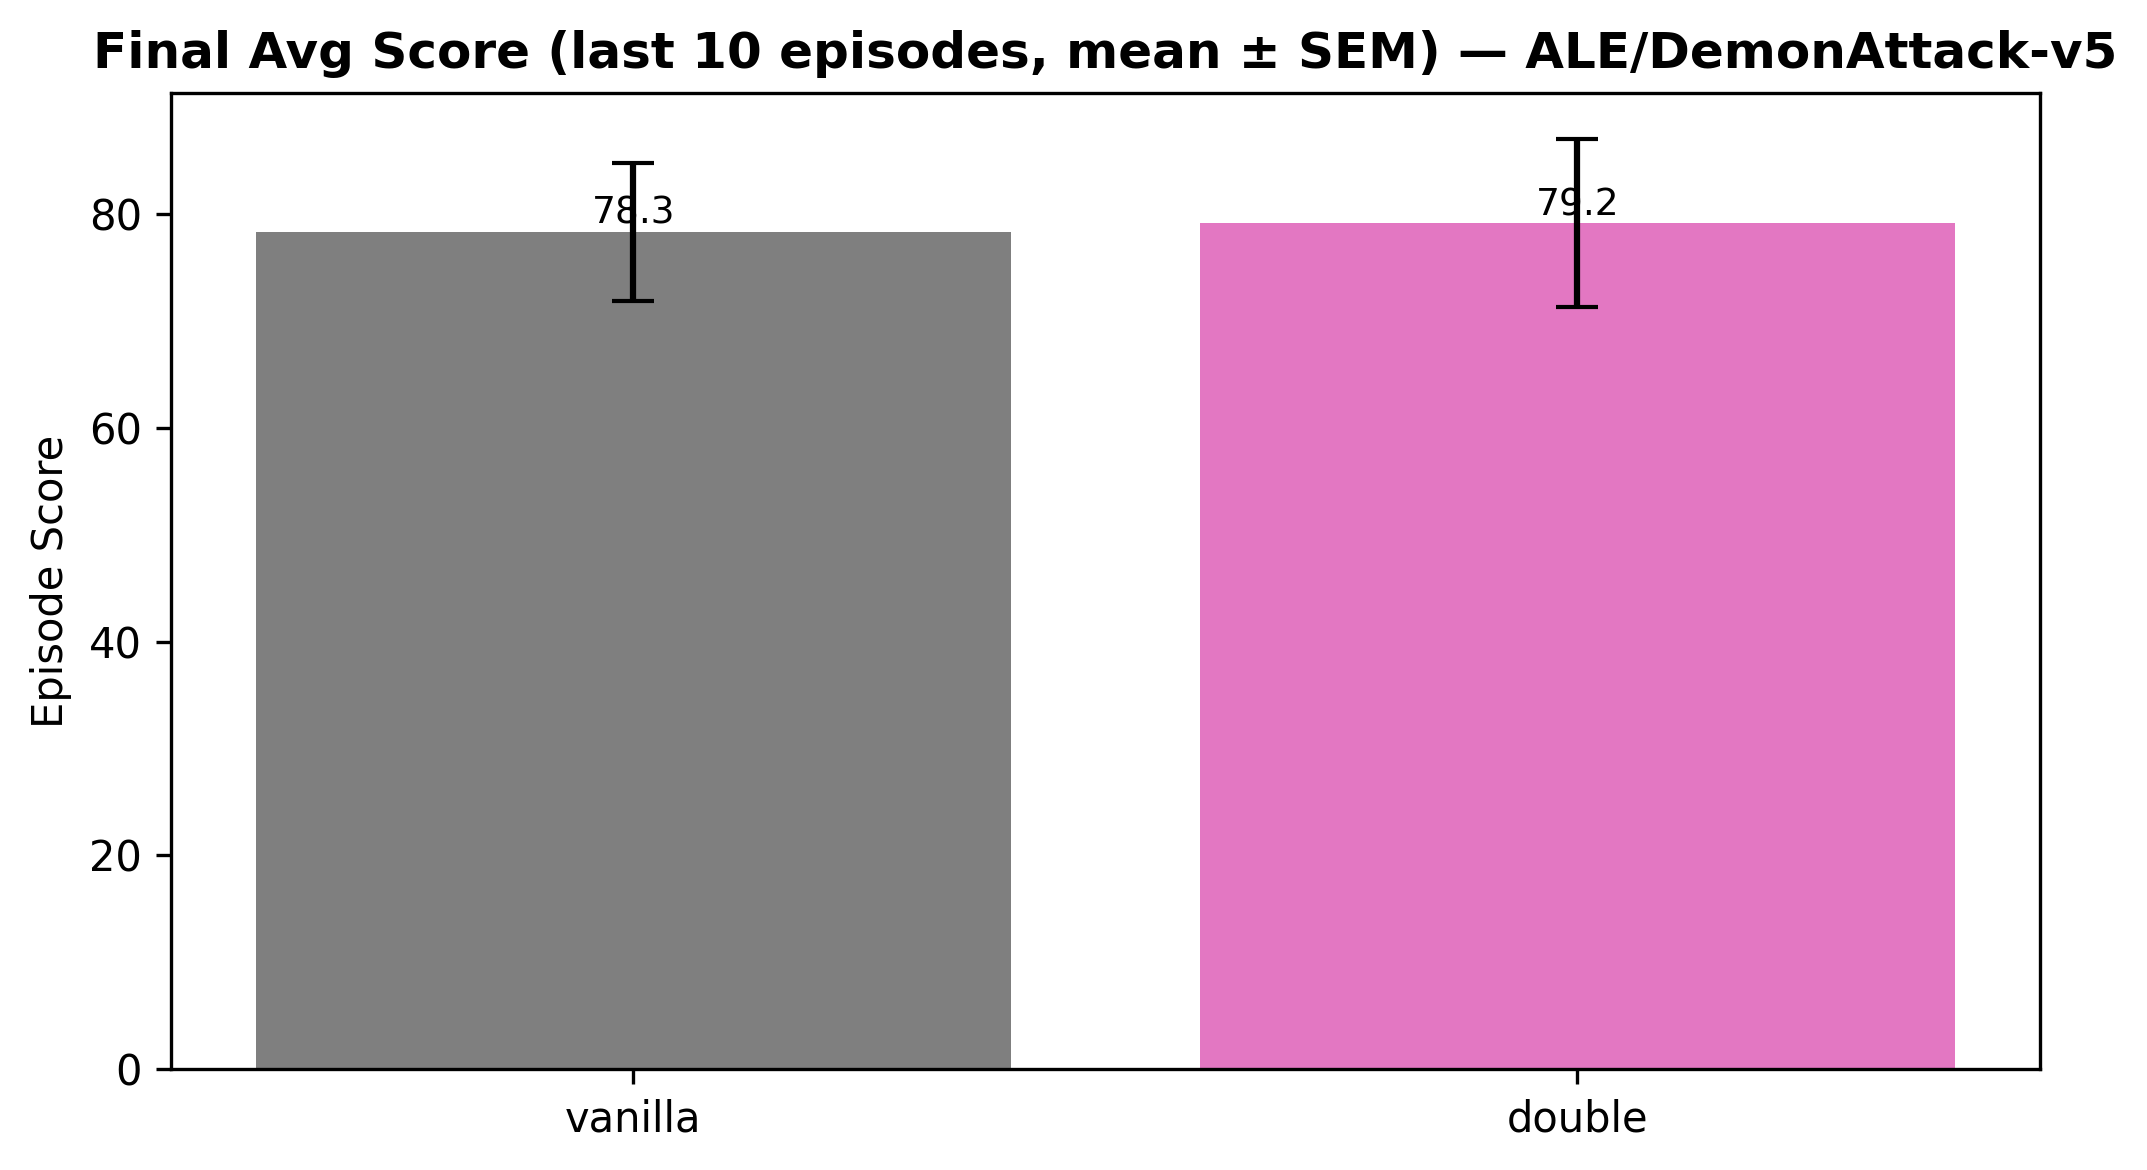

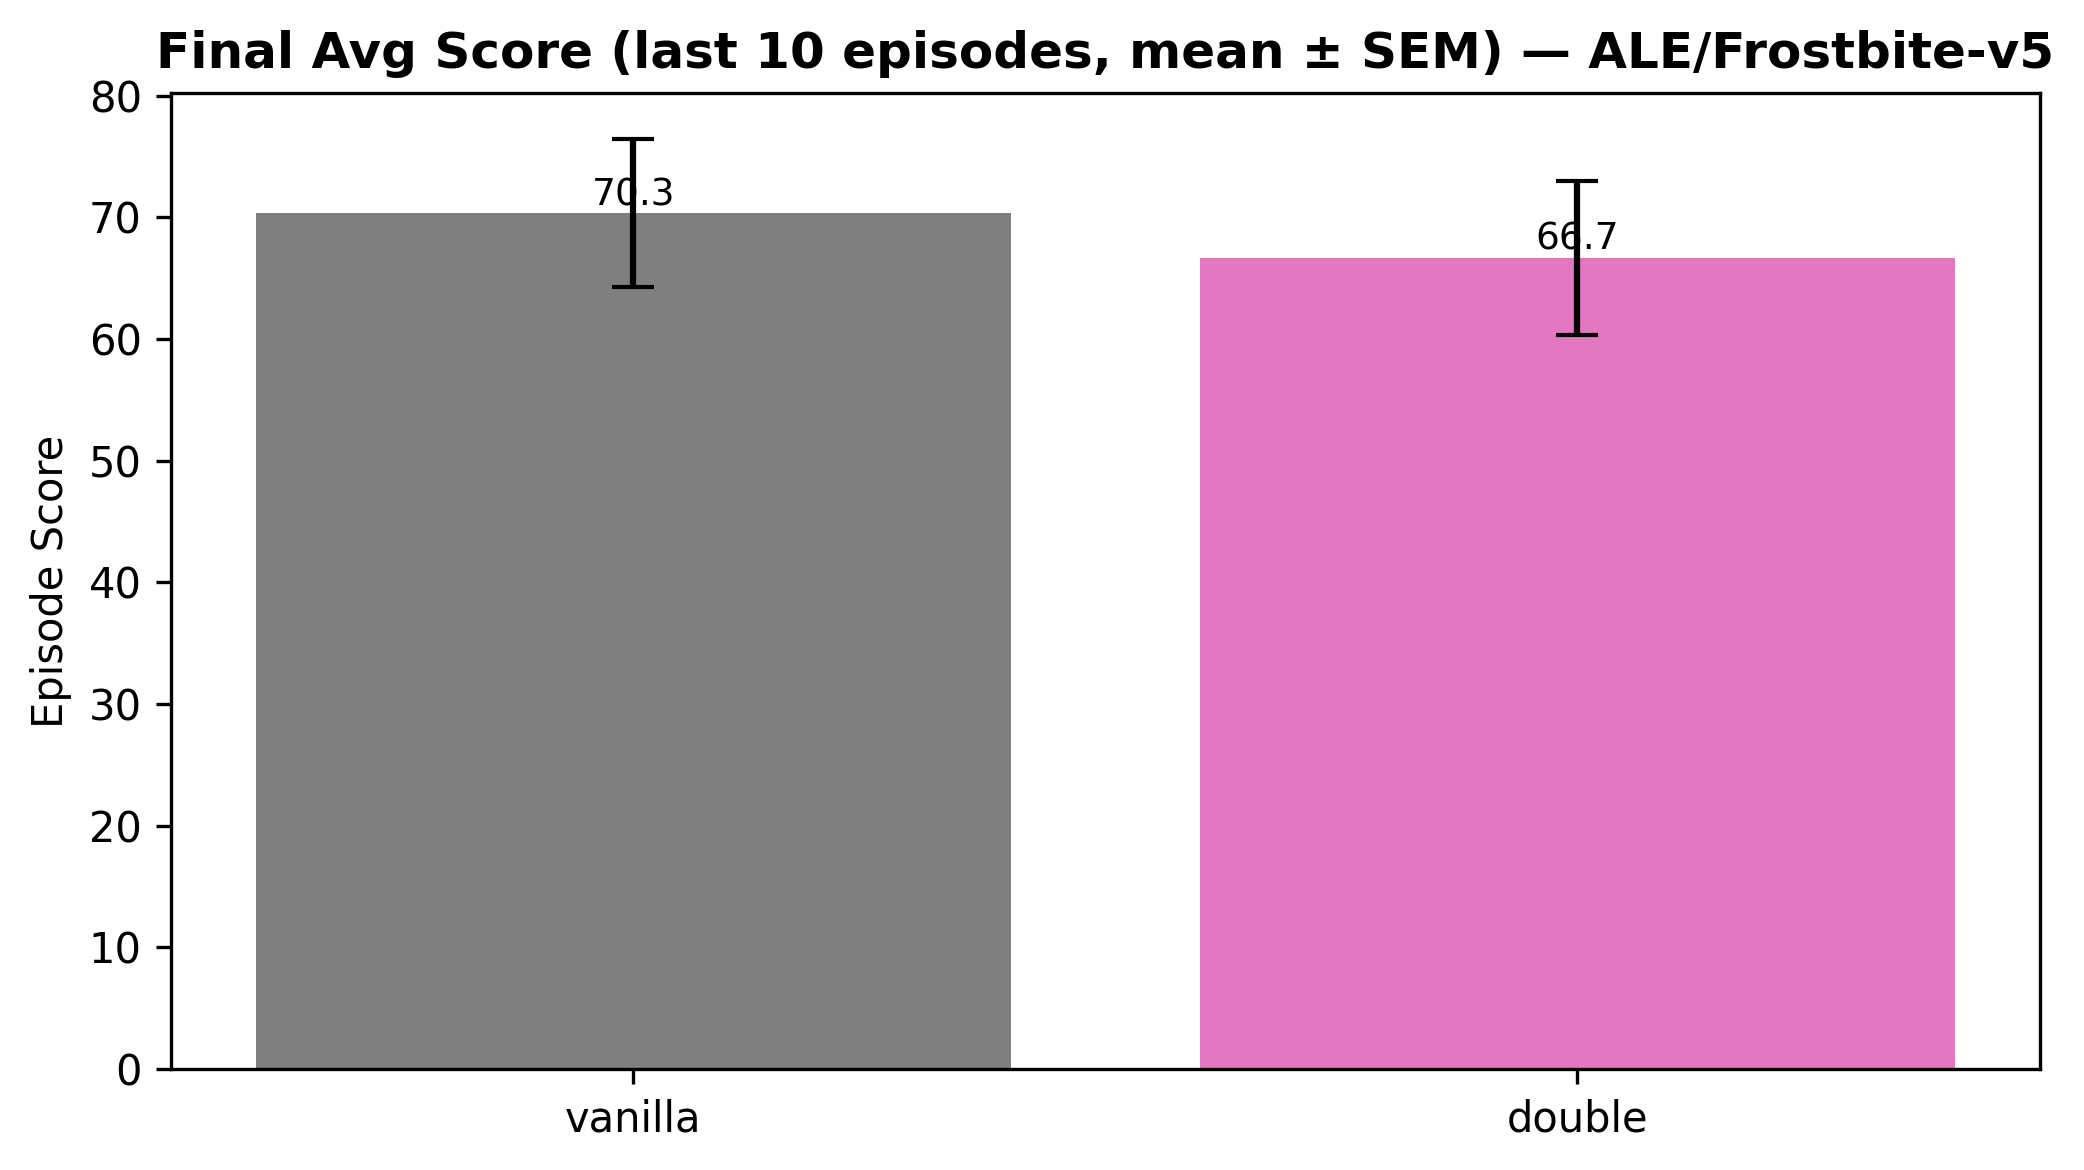

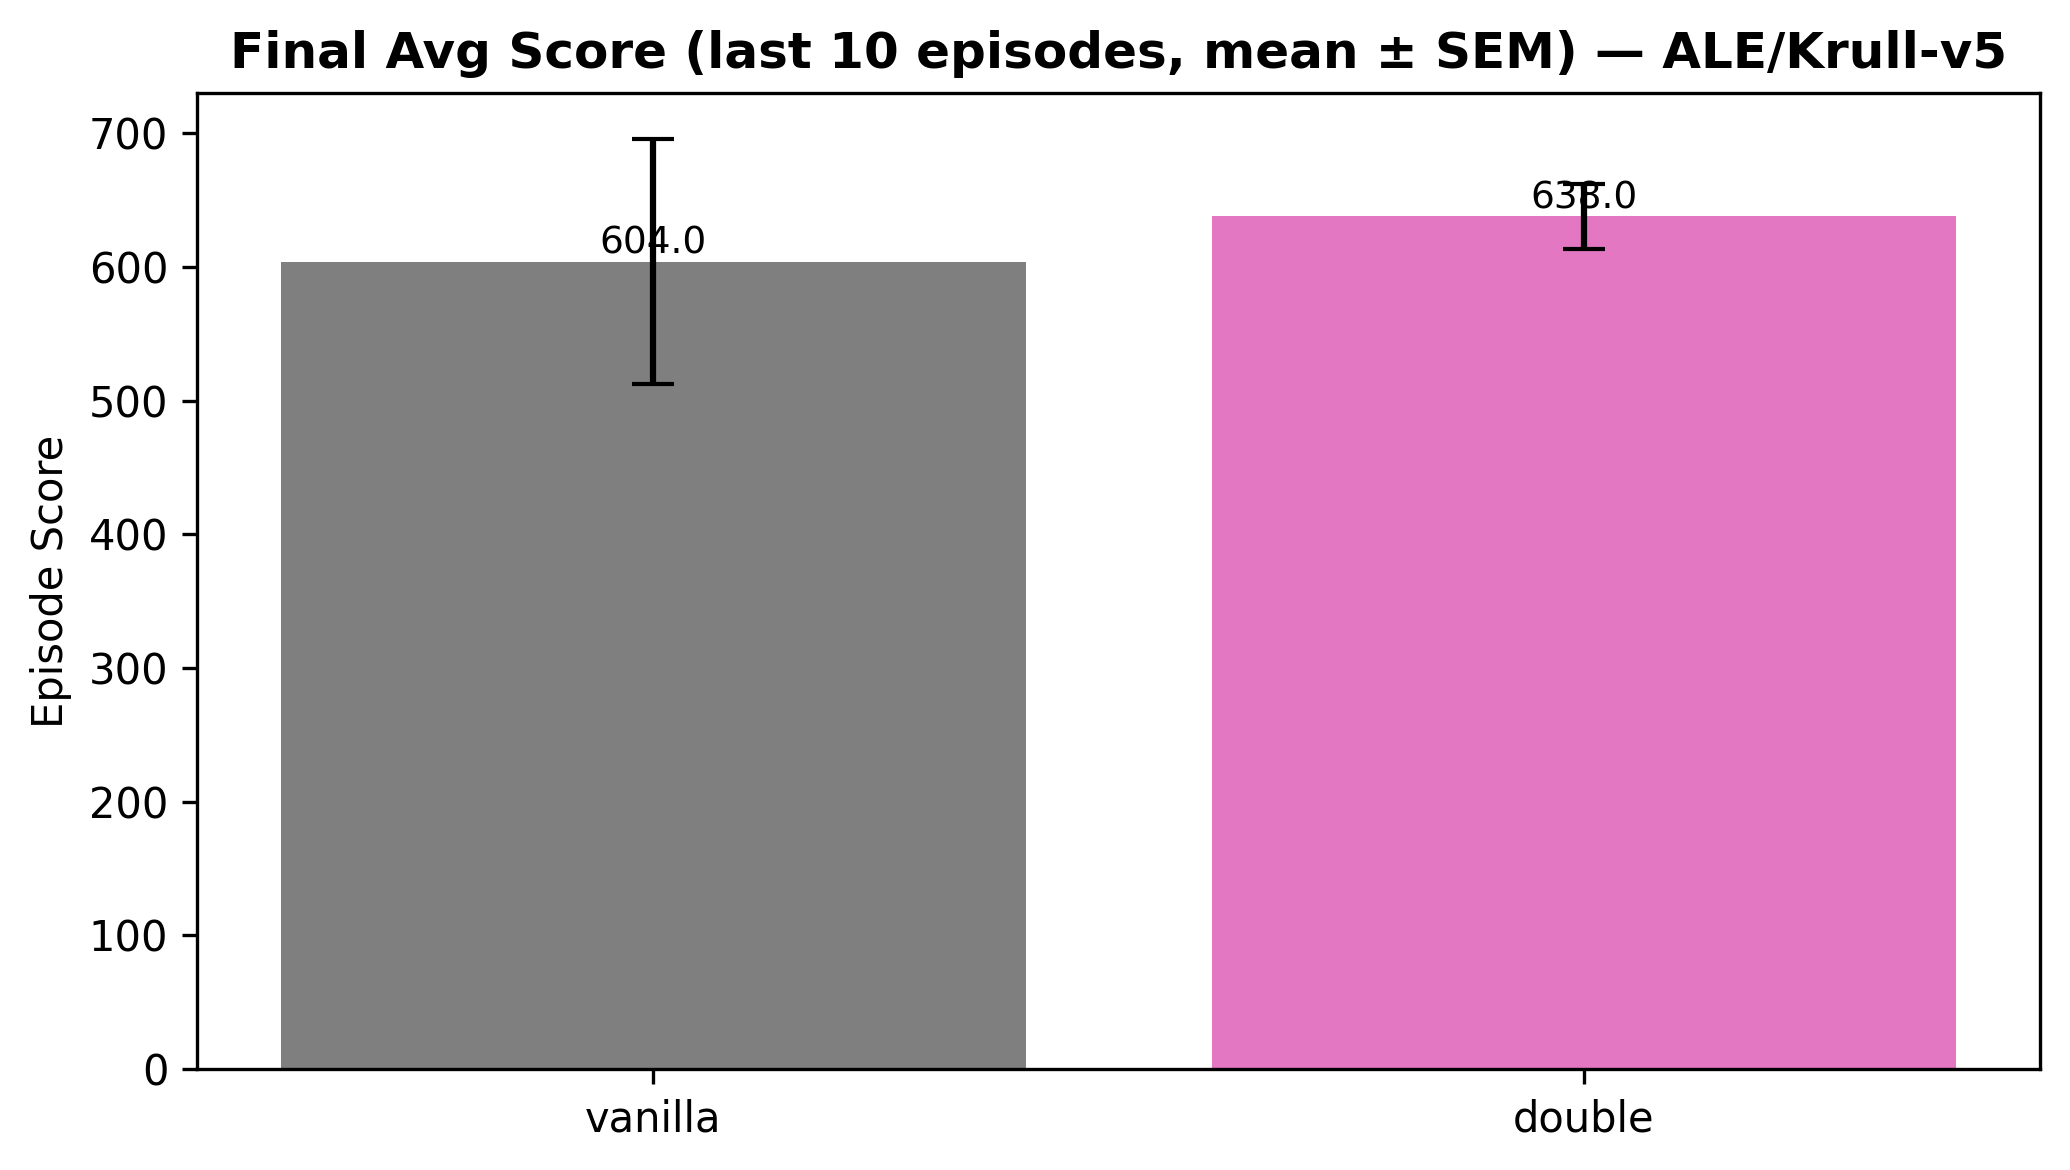

In [23]:
for env_name in ENVIRONMENTS:
    env_results = [r for r in results if r["env_name"] == env_name]
    
    # Group results by unique component tag
    unique_tags = list(dict.fromkeys([r["tag"] for r in env_results]))
    mean_scores = []
    sem_scores = []
    
    for tag in unique_tags:
        tag_runs = [r for r in env_results if r["tag"] == tag]
        # Calculate recent average score for each seed run
        seed_finals = [np.mean(r["scores"][-10:]) if r["scores"] else 0.0 for r in tag_runs]
        mean_scores.append(np.mean(seed_finals))
        sem_scores.append(np.std(seed_finals) / np.sqrt(len(seed_finals)) if len(seed_finals) > 1 else 0.0)
    
    plt.figure(figsize=(7, 4), dpi=300)
    bars = plt.bar(unique_tags, mean_scores, yerr=sem_scores, capsize=5,
                   color=["#7f7f7f", "#e377c2", "#1f77b4"][:len(unique_tags)])
    plt.title(f"Final Avg Score (last 10 episodes, mean ± SEM) — {env_name}", fontsize=12, fontweight="bold")
    plt.ylabel("Episode Score", fontsize=10)
    plt.xticks(rotation=0)
    
    for bar, score in zip(bars, mean_scores):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{score:.1f}",
                 ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

## Combined Learning Curves

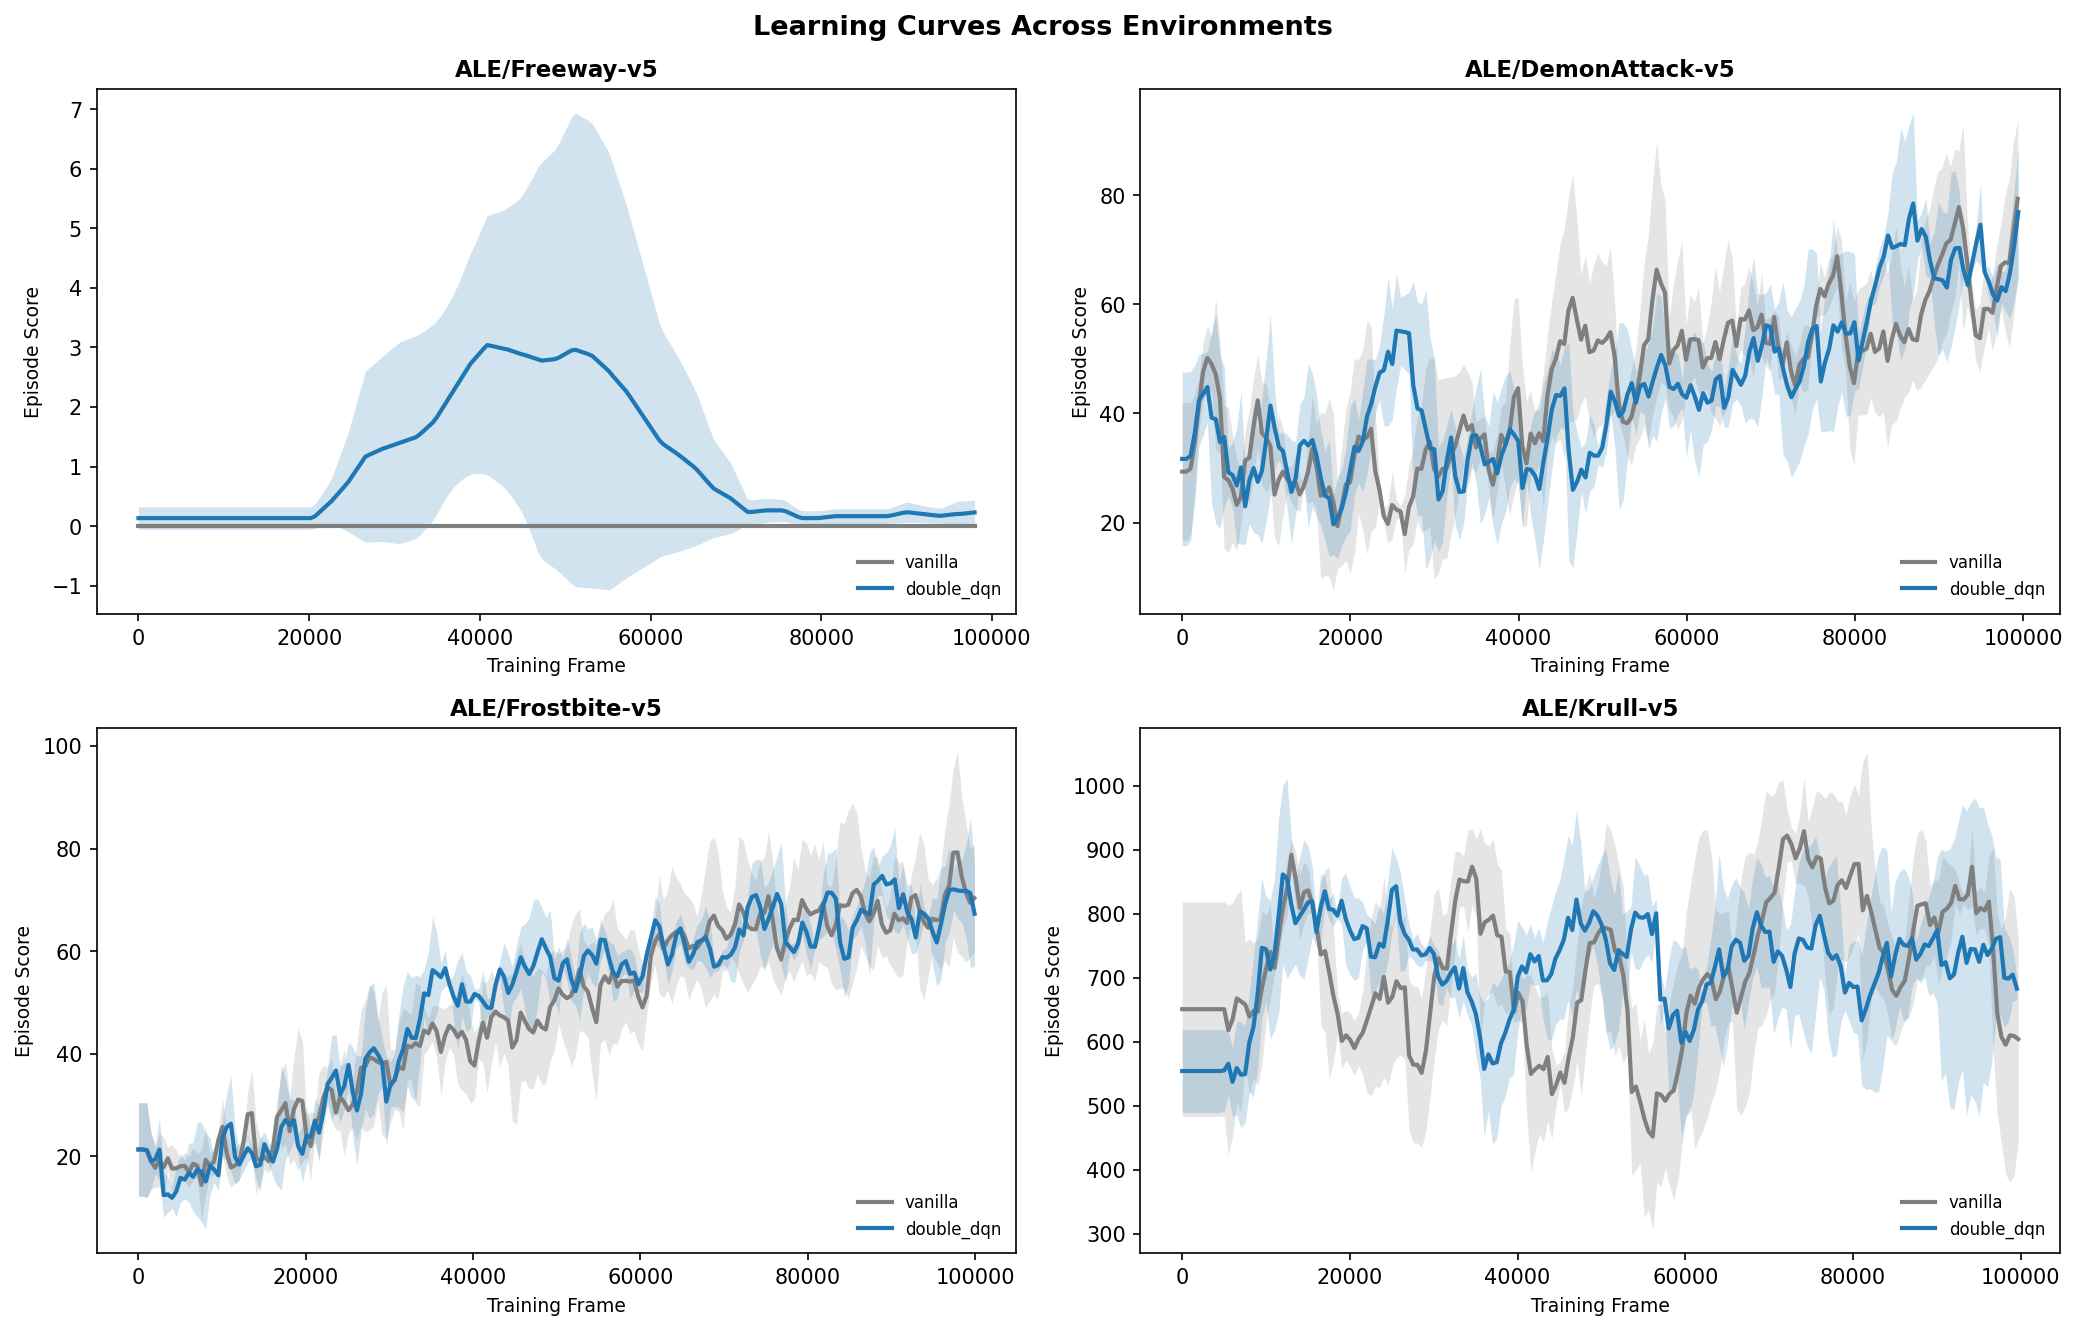

In [24]:
# Combined learning curves — one figure, one subplot per environment
n_envs = len(ENVIRONMENTS)
ncols = 2
nrows = int(np.ceil(n_envs / ncols))

colors = {"vanilla": "#7f7f7f", "dueling": "#e377c2", "double_dqn": "#1f77b4"}



fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.5 * nrows), dpi=150)
axes = np.array(axes).reshape(-1)  # flatten in case of a single row


for ax, env_name in zip(axes, ENVIRONMENTS):
    for exp_name in EXPERIMENTS:
        agg = aggregate_seeds_by_frame(results, env_name, exp_name, key="scores", window_size=10, band="std")
        if agg is None:
            continue
        frames, center, lower, upper = agg
        color = colors.get(exp_name)
        ax.plot(frames, center, linewidth=2.0, color=color, label=exp_name)
        ax.fill_between(frames, lower, upper, color=color, alpha=0.2, linewidth=0)
    ax.set_title(env_name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Training Frame", fontsize=9)
    ax.set_ylabel("Episode Score", fontsize=9)
    ax.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="none", fontsize=8)


# Hide any unused subplot slots (e.g. 4 envs on a grid sized for more)
for ax in axes[n_envs:]:
    ax.axis("off")

plt.suptitle("Learning Curves Across Environments", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Compute Entropy - Action Diversity

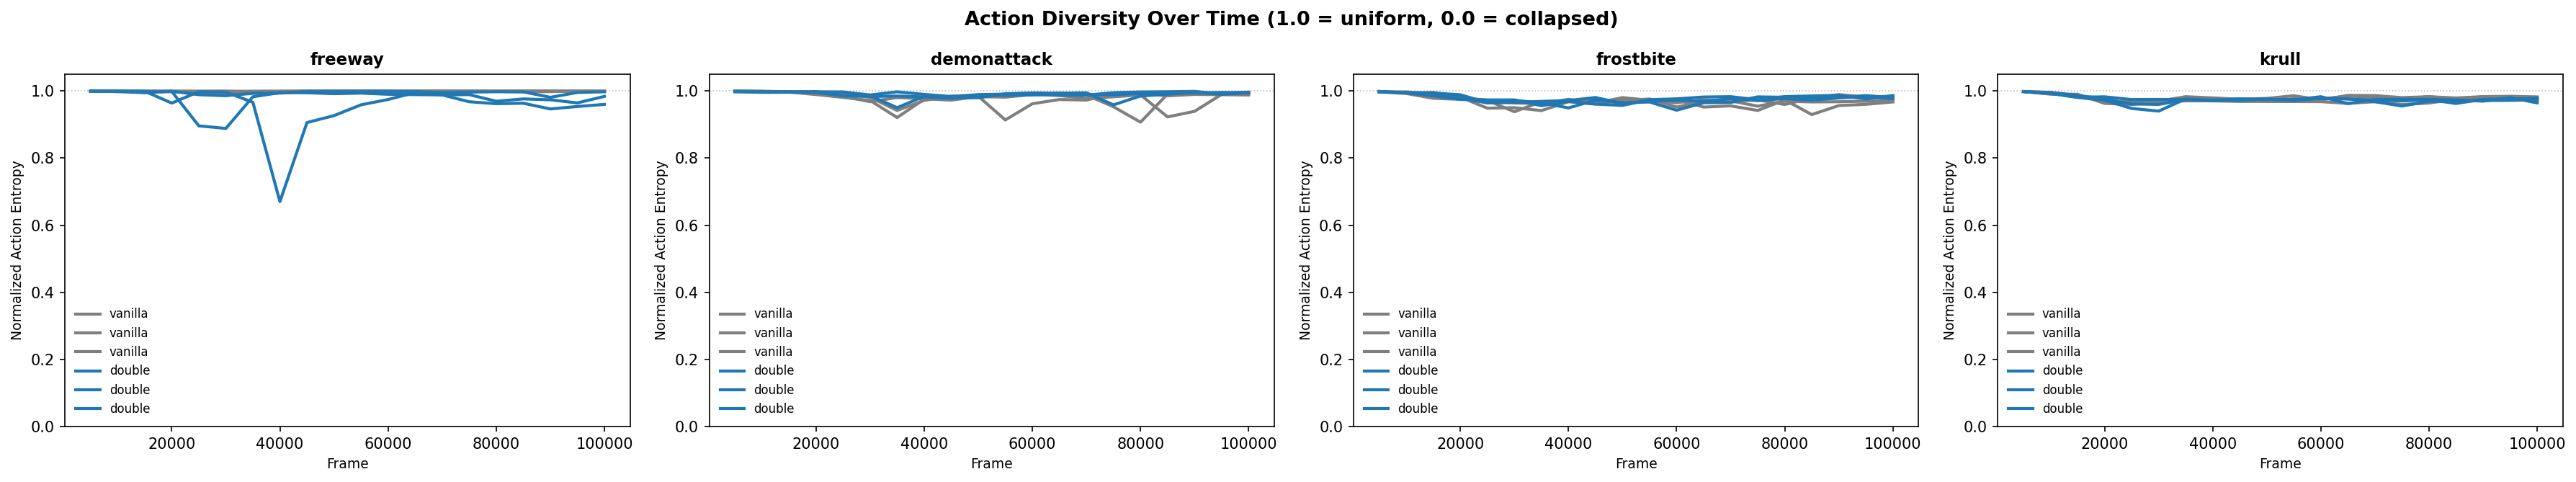

In [25]:
def compute_entropy_series(action_history: list) -> tuple:
    """Converts a list of (frame, pct_vector) into (frames, normalized_entropy)."""
    frames, pct_list = zip(*action_history)
    pct_matrix = np.array(pct_list)
    action_dim = pct_matrix.shape[1]

    # Avoid log(0) for actions with zero share in a given window
    with np.errstate(divide="ignore", invalid="ignore"):
        entropy = -np.nansum(pct_matrix * np.log(pct_matrix, where=pct_matrix > 0), axis=1)

    normalized_entropy = entropy / np.log(action_dim)
    return frames, normalized_entropy


fig, axes = plt.subplots(1, n_envs, figsize=(6 * n_envs, 4.5), dpi=150)
axes = np.atleast_1d(axes)

for ax, env_name in zip(axes, ENVIRONMENTS):
    for r in results:
        if r["env_name"] != env_name or not r["action_history"]:
            continue
        frames, norm_entropy = compute_entropy_series(r["action_history"])
        ax.plot(frames, norm_entropy, linewidth=2.0, color=colors.get(r["experiment"]), label=r["tag"])

    ax.set_ylim(0, 1.05)
    ax.axhline(1.0, color="gray", linewidth=0.8, linestyle=":", alpha=0.5)
    ax.set_title(get_env_short_name(env_name), fontsize=11, fontweight="bold")
    ax.set_xlabel("Frame", fontsize=9)
    ax.set_ylabel("Normalized Action Entropy", fontsize=9)
    ax.legend(loc="lower left", frameon=True, facecolor="white", edgecolor="none", fontsize=8)

plt.suptitle("Action Diversity Over Time (1.0 = uniform, 0.0 = collapsed)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#  Component-specific Ablations

# Double DQN

## Holdout Q-Drift Plot

In [26]:
def aggregate_qdrift_seeds(results: list, env_name: str, exp_name: str, band: str = "std"):
    """Aggregates holdout Q-drift across seeds for one (env, experiment) pair.

    q_drift entries are (frame, q_value) tuples logged on a fixed periodic
    schedule (independent of episode-length randomness), so — unlike
    per-episode `scores` — no per-seed smoothing is needed before stacking.
    Truncates to the shortest seed's length as a safety margin, and warns
    if the seeds' frame axes don't actually line up (stacking by index would
    silently misalign values if they don't).

    band: "std" for mean +/- 1 std, "iqr" for median with 25th/75th percentile
    band. With few seeds, "std" is the more honest choice.
    """
    qdrift_list = [
        r["q_drift"] for r in results
        if r["env_name"] == env_name and r["experiment"] == exp_name and r["q_drift"]
    ]
    if not qdrift_list:
        return None

    min_len = min(len(q) for q in qdrift_list)
    if min_len == 0:
        return None

    frames = [f for f, _ in qdrift_list[0][:min_len]]
    for q in qdrift_list[1:]:
        other_frames = [f for f, _ in q[:min_len]]
        if other_frames != frames:
            print(f"[warning] Q-drift frame axes differ across seeds for "
                  f"({env_name}, {exp_name}) — band may be misaligned.")
            break

    stacked = np.array([[v for _, v in q[:min_len]] for q in qdrift_list])  # (n_seeds, min_len)

    if band == "iqr":
        center = np.median(stacked, axis=0)
        lower = np.percentile(stacked, 25, axis=0)
        upper = np.percentile(stacked, 75, axis=0)
    else:
        center = stacked.mean(axis=0)
        spread = stacked.std(axis=0)
        lower = center - spread
        upper = center + spread

    return frames, center, lower, upper

Generating Double DQN Q-Overestimation Plots...
Figure saved to: figures/Holdout_Q_Value_Drift.png


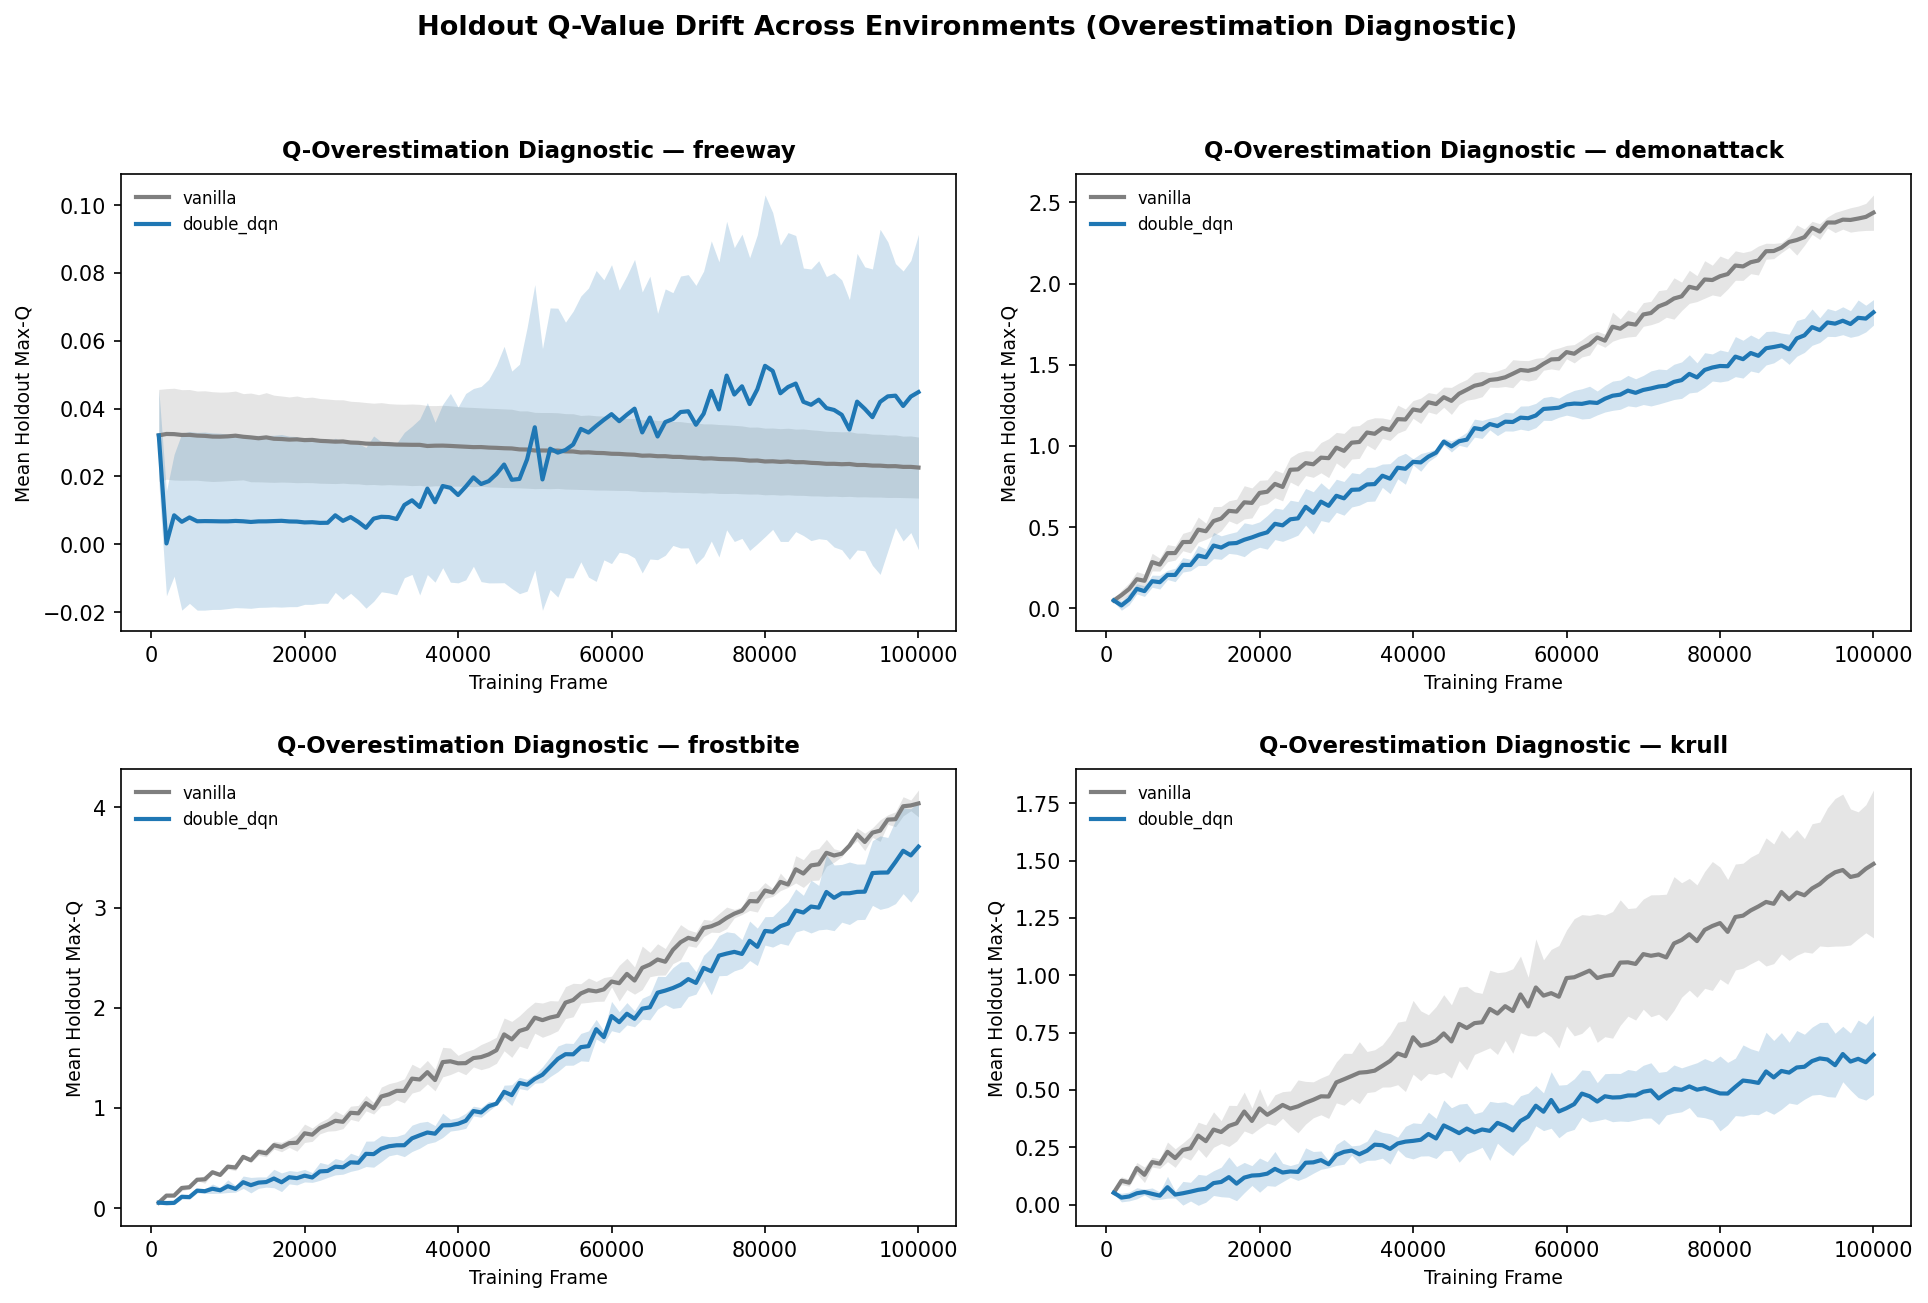

In [31]:
# ==============================================================================
# LOCATION: Double DQN Holdout Q-Drift Plotting Cell
# ==============================================================================
has_qdrift_data = any(len(r.get("q_drift", [])) > 0 for r in results)

if has_qdrift_data:
    print("Generating Double DQN Q-Overestimation Plots...")
    
    # Filter for environments with active Q-drift data
    active_envs = [
        e for e in ENVIRONMENTS 
        if any(r["env_name"] == e and len(r.get("q_drift", [])) > 0 for r in results)
    ]
    
    n_envs = len(active_envs)
    ncols = min(2, max(1, n_envs))
    nrows = int(np.ceil(n_envs / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.5 * nrows), dpi=150, squeeze=False)
    
    # === [FIX]: Explicitly flatten the 2D axes array ===
    axes_flat = axes.flatten()
    
    for idx, env_name in enumerate(active_envs):
        ax = axes_flat[idx]
        
        # Plot both Vanilla and Double DQN for direct comparison
        for exp_name in ["vanilla", "double_dqn"]:
            agg = aggregate_qdrift_seeds(results, env_name, exp_name, band="std")
            if agg is None:
                continue
            frames, center, lower, upper = agg
            color = colors.get(exp_name, "#1f77b4" if exp_name == "double_dqn" else "#7f7f7f")
            
            ax.plot(frames, center, linewidth=2.0, color=color, label=exp_name)
            ax.fill_between(frames, lower, upper, color=color, alpha=0.2, linewidth=0)
            
        ax.set_title(f"Q-Overestimation Diagnostic — {get_env_short_name(env_name)}", fontsize=11, fontweight="bold", pad=8)
        ax.set_xlabel("Training Frame", fontsize=9)
        ax.set_ylabel("Mean Holdout Max-Q", fontsize=9)
        ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none", fontsize=8)
        
    # === [FIX]: Safely hide unused subplot slots ===
    for idx in range(n_envs, len(axes_flat)):
        axes_flat[idx].axis("off")
        
    # === [FIX]: Suptitle positioned cleanly with reserved top margin ===
    plt.suptitle(
        "Holdout Q-Value Drift Across Environments (Overestimation Diagnostic)", 
        fontsize=13, 
        fontweight="bold", 
        y=0.98
    )
    plt.tight_layout(rect=[0, 0.02, 1, 0.94], h_pad=2.0)
    save_and_show("Holdout_Q_Value_Drift.png")
else:
    print("Skipping Double DQN Q-Drift Viz: No Q-drift tracking data found in results.")

Generating Double DQN Q-Overestimation Plots...


NameError: name 'axes_flat' is not defined

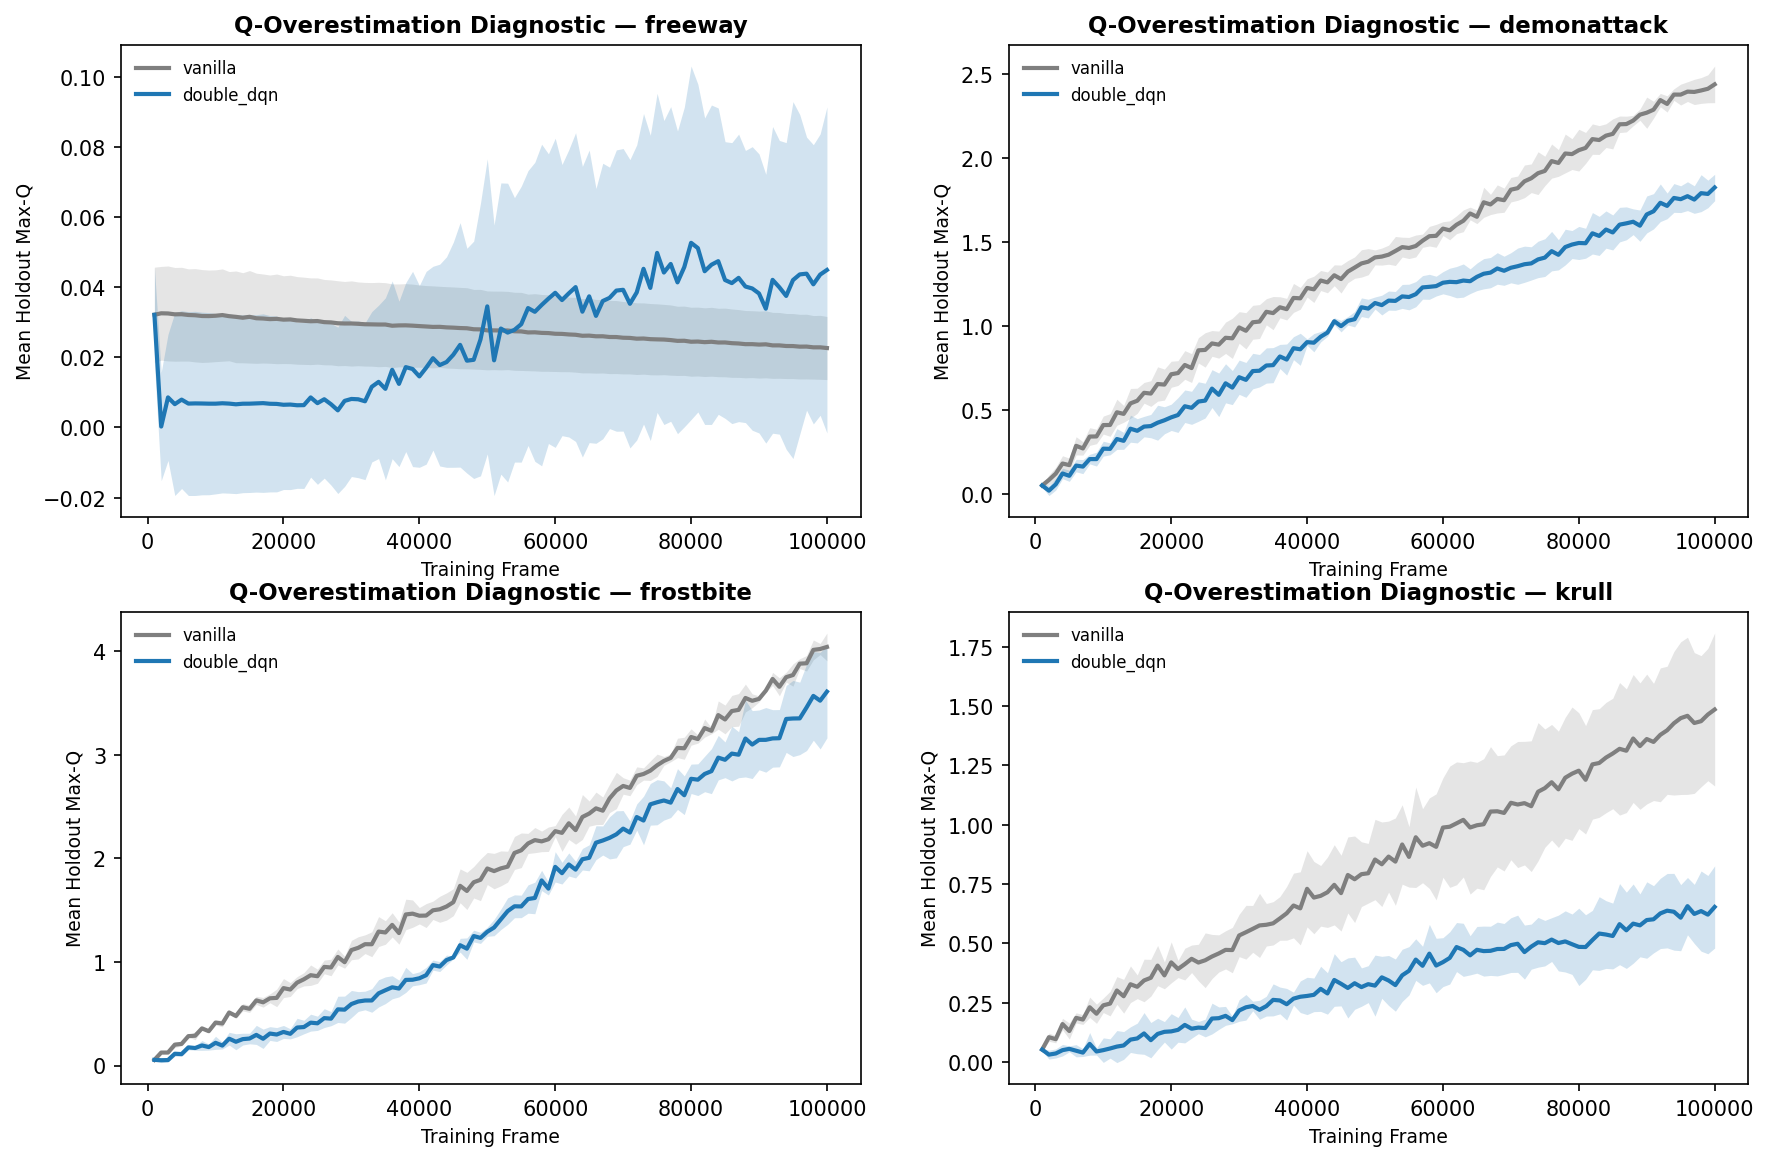

In [27]:
# ==============================================================================
# 1. DOUBLE DQN SPECIFIC VIZ: Q-Overestimation Diagnostic
# ==============================================================================
has_qdrift_data = any(len(r.get("q_drift", [])) > 0 for r in results)

if has_qdrift_data:
    print("Generating Double DQN Q-Overestimation Plots...")
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.5 * nrows), dpi=150)
    axes = np.array(axes).reshape(-1)
    
    for ax, env_name in zip(axes, ENVIRONMENTS):
        # Only compare vanilla and double_dqn experiments for Q-drift
        for exp_name in ["vanilla", "double_dqn"]:
            if exp_name not in EXPERIMENTS:
                continue
            agg = aggregate_qdrift_seeds(results, env_name, exp_name, band="std")
            if agg is None:
                continue
            frames, center, lower, upper = agg
            color = colors.get(exp_name, "#1f77b4")
            ax.plot(frames, center, linewidth=2.0, color=color, label=exp_name)
            ax.fill_between(frames, lower, upper, color=color, alpha=0.2, linewidth=0)
            
        ax.set_title(f"Q-Overestimation Diagnostic — {get_env_short_name(env_name)}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Training Frame", fontsize=9)
        ax.set_ylabel("Mean Holdout Max-Q", fontsize=9)
        ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none", fontsize=8)
        
    for idx in range(n_envs, len(axes_flat)):
            axes_flat[idx].axis("off")
        
    plt.suptitle("Holdout Q-Value Drift Across Environments (Overestimation Diagnostic)", 
                 fontsize=13, fontweight="bold", y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    plt.show()
else:
    print("Skipping Double DQN Q-Drift Viz: No Q-drift tracking data found in results.")

# Dueling DQN

## Value-stream vs. advantage-stream magnitude over training

In [ ]:
# Multi-seed aggregator for Dueling V(s) and Advantage spread series 
def aggregate_dueling_seeds(results: list, env_name: str, exp_name: str = "dueling"):
    """Aggregates mean |V(s)| and Advantage spread across seeds for Dueling DQN."""
    runs = [
        r["dueling_metrics"] for r in results 
        if r["env_name"] == env_name and r["experiment"] == exp_name and r.get("dueling_metrics")
    ]
    if not runs:
        return None
    
    min_len = min(len(m) for m in runs)
    if min_len == 0:
        return None
        
    frames = [f for f, _, _ in runs[0][:min_len]]
    v_stacked = np.array([[v for _, v, _ in m[:min_len]] for m in runs])      # Shape: (n_seeds, min_len)
    adv_stacked = np.array([[a for _, _, a in m[:min_len]] for m in runs])    # Shape: (n_seeds, min_len)
    
    v_mean, v_std = v_stacked.mean(axis=0), v_stacked.std(axis=0)
    adv_mean, adv_std = adv_stacked.mean(axis=0), adv_stacked.std(axis=0)
    
    return frames, (v_mean, v_std), (adv_mean, adv_std)

In [ ]:
# Component-guarded visualization for Dueling Stream Dynamics
has_dueling = any(len(r.get("dueling_metrics", [])) > 0 for r in results)

if has_dueling:
    print("Generating Dueling DQN Stream Decomposition Plots...")
    n_envs = len(ENVIRONMENTS)
    fig, axes = plt.subplots(n_envs, 2, figsize=(14, 4.5 * n_envs), dpi=150, squeeze=False)
    
    for row_idx, env_name in enumerate(ENVIRONMENTS):
        agg = aggregate_dueling_seeds(results, env_name, exp_name="dueling")
        if agg is None:
            continue
            
        frames, (v_mean, v_std), (adv_mean, adv_std) = agg
        short_name = get_env_short_name(env_name)
        
        # Left Subplot: State-Value Stream Magnitude E[|V(s)|]
        ax_v = axes[row_idx, 0]
        ax_v.plot(frames, v_mean, color="#e377c2", linewidth=2.0, label="Mean |V(s)|")
        ax_v.fill_between(frames, v_mean - v_std, v_mean + v_std, color="#e377c2", alpha=0.2)
        ax_v.set_title(f"State-Value Stream Scale |V(s)| — {short_name}", fontsize=11, fontweight="bold")
        ax_v.set_xlabel("Training Frame", fontsize=9)
        ax_v.set_ylabel("Mean |V(s)|", fontsize=9)
        ax_v.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none", fontsize=8)
        
        # Right Subplot: Advantage Stream Spread E[max_a A(s,a) - min_a A(s,a)]
        ax_adv = axes[row_idx, 1]
        ax_adv.plot(frames, adv_mean, color="#9467bd", linewidth=2.0, label="Advantage Spread")
        ax_adv.fill_between(frames, adv_mean - adv_std, adv_mean + adv_std, color="#9467bd", alpha=0.2)
        ax_adv.set_title(f"Advantage Gap (max A - min A) — {short_name}", fontsize=11, fontweight="bold")
        ax_adv.set_xlabel("Training Frame", fontsize=9)
        ax_adv.set_ylabel("Mean Advantage Spread", fontsize=9)
        ax_adv.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none", fontsize=8)
        
    plt.suptitle("Dueling DQN: Value vs. Advantage Stream Decomposition", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Dueling DQN Viz: No dueling stream data found in results.")

# N-step Accumulator

## TD-error magnitude distribution (histogram at a few checkpoints)

In [ ]:
# Multi-seed aggregator for TD-error distributions at checkpoints ===
def aggregate_td_error_checkpoints(results: list, env_name: str, exp_name: str):
    """Combines TD-error snapshots across seeds for each checkpoint frame."""
    runs = [
        r["td_error_checkpoints"] for r in results 
        if r["env_name"] == env_name and r["experiment"] == exp_name and r.get("td_error_checkpoints")
    ]
    if not runs:
        return {}
    
    # Collect all common frame milestone keys
    common_frames = sorted(list(set.intersection(*[set(r.keys()) for r in runs])))
    aggregated = {}
    for f in common_frames:
        # Concatenate TD errors from all seeds at milestone frame f
        all_errors = np.concatenate([np.abs(r[f]).flatten() for r in runs])
        aggregated[f] = all_errors
    return aggregated

In [ ]:
# Component-guarded visualization for N-Step vs 1-Step TD Error Distributions ===
has_nstep_data = any(len(r.get("td_error_checkpoints", {})) > 0 for r in results if "nstep" in r.get("tag", ""))
has_vanilla_data = any(len(r.get("td_error_checkpoints", {})) > 0 for r in results if r.get("tag") == "vanilla")

if has_nstep_data and has_vanilla_data:
    print("Generating N-Step vs. 1-Step TD-Error Distribution Plots...")
    
    for env_name in ENVIRONMENTS:
        vanilla_td = aggregate_td_error_checkpoints(results, env_name, exp_name="vanilla")
        nstep_td = aggregate_td_error_checkpoints(results, env_name, exp_name="multi_step")
        
        # Match available milestone frames between Vanilla and N-step
        milestone_frames = sorted(list(set(vanilla_td.keys()).intersection(set(nstep_td.keys()))))
        if not milestone_frames:
            continue
            
        ncols = len(milestone_frames)
        fig, axes = plt.subplots(1, ncols, figsize=(4.5 * ncols, 3.8), dpi=150, squeeze=False)
        short_name = get_env_short_name(env_name)
        
        for col_idx, f in enumerate(milestone_frames):
            ax = axes[0, col_idx]
            v_errs = vanilla_td[f]
            n_errs = nstep_td[f]
            
            # Robust x-limit (clip at 98th percentile of combined data to ignore extreme visual outliers)
            max_val = np.percentile(np.concatenate([v_errs, n_errs]), 98) if len(v_errs) and len(n_errs) else 1.0
            bins = np.linspace(0, max_val, 30)
            
            # Density histograms
            ax.hist(v_errs, bins=bins, density=True, alpha=0.5, color="#7f7f7f", label="1-Step (Vanilla)")
            ax.hist(n_errs, bins=bins, density=True, alpha=0.5, color="#1f77b4", label="N-Step")
            
            # Mean markers
            ax.axvline(np.mean(v_errs), color="#404040", linestyle="--", linewidth=1.2, label=f"1-Step Mean ({np.mean(v_errs):.2f})")
            ax.axvline(np.mean(n_errs), color="#0b4073", linestyle="--", linewidth=1.2, label=f"N-Step Mean ({np.mean(n_errs):.2f})")
            
            ax.set_title(f"Frame {f:,}", fontsize=10, fontweight="bold")
            ax.set_xlabel("|TD-Error| Magnitude", fontsize=9)
            if col_idx == 0:
                ax.set_ylabel("Probability Density", fontsize=9)
            ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", fontsize=7)
            ax.set_xlim(0, max_val)
            
        plt.suptitle(f"TD-Error Magnitude Distribution over Time — {short_name} (Bias/Variance Signature)", 
                     fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()
else:
    print("Skipping N-Step TD-Error Viz: Requires both Vanilla and N-step checkpoint data.")

# Combined final-score comparison 

In [ ]:
# Combined final-score comparison — one grouped bar chart across all environments
exp_names = list(EXPERIMENTS.keys())
x = np.arange(len(ENVIRONMENTS))
width = 0.8 / len(exp_names)
plt.figure(figsize=(9, 5), dpi=150)

for i, exp_name in enumerate(exp_names):
    scores_for_exp = []
    for env_name in ENVIRONMENTS:
        matches = [r for r in results if r["env_name"] == env_name and r["experiment"] == exp_name]
        # Average over all seeds for this (env, exp) pair
        seed_finals = [np.mean(r["scores"][-10:]) for r in matches if r["scores"]]
        avg_score = float(np.mean(seed_finals)) if seed_finals else 0.0
        scores_for_exp.append(avg_score)
        
    plt.bar(x + i * width, scores_for_exp, width=width,
            label=exp_name, color=colors.get(exp_name))

plt.xticks(x + width * (len(exp_names) - 1) / 2, [get_env_short_name(e) for e in ENVIRONMENTS])
plt.title("Final Avg Score (last 10 episodes across seeds) by Environment", fontsize=12, fontweight="bold")
plt.ylabel("Episode Score", fontsize=10)
plt.legend(frameon=True, facecolor="white", edgecolor="none")
plt.tight_layout()
plt.show()